# CoAlign — alignment-externality analysis (full data)

Port of `empirics_412/412_alignment_externalities.ipynb` to the Community Alignment Dataset.

**Inputs**
- `features_full_nofb.parquet` — (3,380 × 15) lookup, response_text → 15-dim score, produced by `embed_and_project.py` (Qwen3-Embedding-8B → V from `coalign_50_dimensions.tar.gz`).
- `pairwise_comparisons_ge10_nofb.parquet` — 42,693 pairwise choices over 1,069 annotators in 5 countries.

**Pipeline.** Setup (§1) → BTL (§2) → impact ψ + identity check (§3) → welfare-optimal ψ\* (§5) → impact gap Δψ + per-agent ΔW (§6) → participation externality Γ via LOO BTL + country grouping + KMeans cohorts (§7).

**Tunables in §1.** `MIN_ROWS` (per-annotator filter — bump higher for cleaner per-user BTL at the cost of fewer agents) and `GROUP_BY` (`annotator_country`, `annotator_gender`, `annotator_political`, `annotator_age`, etc. — drives the §6 histogram coloring and §7 group-pair Γ summary, doesn't change any per-person quantity).

## §1. Setup — load full Qwen3-projected feature lookup, filter pairwise data

In [2]:
from __future__ import annotations
import json, tarfile, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy.special import expit as sigmoid
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from joblib import Parallel, delayed

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110
np.random.seed(0)

FEATURES_FULL = Path("features_full_nofb.parquet")    # produced by embed_and_project.py
TARBALL       = Path("coalign_50_dimensions.tar.gz")
PAIRWISE      = Path("pairwise_comparisons_ge10_nofb.parquet")
MIN_ROWS      = 20         # ≥20 obs/annotator is comfortable for 15-d BTL
BTL_C         = 1.0        # matches food-rescue notebook
GROUP_BY      = "annotator_country"   # try: annotator_gender / annotator_age / annotator_political

if FEATURES_FULL.exists():
    features  = pd.read_parquet(FEATURES_FULL)
    DIM_NAMES = list(features.columns)
    K_DIM     = len(DIM_NAMES)
    print(f"using full Qwen3-projected lookup: {features.shape}")
else:
    # Fallback: 200-option subset from the tarball — only meaningful for the
    # original smoke test (US/India only, ~15 obs/annotator).
    print("features_full.parquet not found — falling back to 200-option tarball subset")
    with tarfile.open(TARBALL) as t:
        bt   = pd.read_csv(t.extractfile("method_llm_gen/outputs/coalign_50/bt_scores.csv"))
        dims = json.loads(t.extractfile("method_llm_gen/outputs/coalign_50/dimensions.json").read())
    DIM_NAMES = [d["name"] for d in dims["dimensions"]]
    K_DIM     = len(DIM_NAMES)
    features  = bt.pivot(index="display_text", columns="dimension_name", values="bt_score")[DIM_NAMES]
    print(f"features (option × dim): {features.shape}")
print(f"dimensions: {DIM_NAMES}")

using full Qwen3-projected lookup: (10417, 15)
dimensions: ['Conciseness', 'Structure', 'Actionability', 'Clarity', 'Emotional Resonance', 'Depth', 'Descriptiveness', 'Sustainability', 'Community Focus', 'Historical Context', 'Practicality', 'Efficiency', 'Creativity', 'Authenticity', 'Formality']


In [3]:
# Filter pairwise data to rows where both options have features.
# With features_full.parquet (3,380 responses) this passes nearly every row;
# with the 200-option fallback it restricts to that subset. Then drop annotators
# with fewer than MIN_ROWS such rows so per-user BTL has enough data to fit.
pw = pd.read_parquet(PAIRWISE)
opt_set = set(features.index)
sub = pw[pw.preferred_text.isin(opt_set) & pw.other_text.isin(opt_set)].copy()
counts = sub.groupby("annotator_id").size()
sub = sub[sub.annotator_id.isin(counts[counts >= MIN_ROWS].index)].reset_index(drop=True)
print(f"subset: {len(sub):,} rows, {sub.annotator_id.nunique()} annotators "
      f"(filtered from {len(pw):,} rows / {pw.annotator_id.nunique()} annotators)")
print(f"  by {GROUP_BY}: {dict(sub[GROUP_BY].value_counts())}")
print(f"  rows/annotator stats: median={sub.groupby('annotator_id').size().median():.0f}, "
      f"min={sub.groupby('annotator_id').size().min()}, "
      f"max={sub.groupby('annotator_id').size().max()}")

subset: 139,125 rows, 2387 annotators (filtered from 143,385 rows / 2868 annotators)
  by annotator_country: {'india': 47643, 'united states': 26349, 'brazil': 22779, 'italy': 21792, 'france': 20562}
  rows/annotator stats: median=57, min=21, max=354


In [4]:
# Build α/y for BTL.
#
# CoAlign gives us only `(preferred, other)` pairs (preferred always wins by construction).
# Logistic regression needs both classes, so we *symmetrize*: each row appears twice,
# once with α = pref − other, y = 1, and once with α = -(pref − other), y = 0.
# This is mathematically equivalent to maximizing Σ_z log σ(α_z^T θ) under L2 regularization.
F = features.loc[sub.preferred_text].to_numpy() - features.loc[sub.other_text].to_numpy()
M = F.shape[0]
alpha_train = np.vstack([F, -F])
y_train     = np.concatenate([np.ones(M), np.zeros(M)]).astype(int)
person_id   = np.concatenate([sub.annotator_id.to_numpy(), sub.annotator_id.to_numpy()])
group_arr   = np.concatenate([sub[GROUP_BY].to_numpy(),    sub[GROUP_BY].to_numpy()])
print(f"alpha_train: {alpha_train.shape}, y_train mean: {y_train.mean():.3f} (=0.5 by symmetrization)")

alpha_train: (278250, 15), y_train mean: 0.500 (=0.5 by symmetrization)


## §2. Per-user + pooled BTL → Θ, $\hat\theta^{\rm RLHF}$, $\bar\theta_w$

In [5]:
def fit_btl_person(alpha, y, C=BTL_C):
    if len(np.unique(y)) < 2:
        return None
    lr = LogisticRegression(fit_intercept=False, C=C, solver="lbfgs", max_iter=2000, tol=1e-8)
    lr.fit(alpha, y)
    return lr.coef_.ravel()

agent_ids, theta_rows, agent_group = [], [], []
for pid in pd.Series(person_id).unique():
    m = person_id == pid
    th = fit_btl_person(alpha_train[m], y_train[m])
    if th is None:
        continue
    agent_ids.append(pid); theta_rows.append(th); agent_group.append(group_arr[m][0])

Theta     = np.vstack(theta_rows)
agent_ids = np.array(agent_ids)
groups    = np.array(agent_group)
N_AGENTS  = Theta.shape[0]
print(f"Theta: {Theta.shape}")
print(f"||θ_n|| stats: mean={np.linalg.norm(Theta,axis=1).mean():.3f}, "
      f"median={np.median(np.linalg.norm(Theta,axis=1)):.3f}, "
      f"max={np.linalg.norm(Theta,axis=1).max():.3f}")
print(f"groups: {dict(pd.Series(groups).value_counts())}")

lr_pool = LogisticRegression(fit_intercept=False, C=BTL_C, solver="lbfgs", max_iter=2000, tol=1e-8)
lr_pool.fit(alpha_train, y_train)
theta_rlhf = lr_pool.coef_.ravel()
weights    = np.full(N_AGENTS, 1/N_AGENTS)
theta_bar  = weights @ Theta
print(f"\n||θ̂_RLHF|| = {np.linalg.norm(theta_rlhf):.3f}")
print(f"||θ̄_w||    = {np.linalg.norm(theta_bar):.3f}")
print(f"cos(θ̄_w, θ̂_RLHF) = {float(theta_bar@theta_rlhf)/(np.linalg.norm(theta_bar)*np.linalg.norm(theta_rlhf)):+.3f}")

comp = pd.DataFrame({"θ̄_w": theta_bar, "θ̂_RLHF": theta_rlhf}, index=DIM_NAMES).round(3)
print(comp.to_string())

Theta: (2387, 15)
||θ_n|| stats: mean=3.001, median=2.971, max=6.255
groups: {'india': 774, 'united states': 448, 'brazil': 425, 'italy': 390, 'france': 350}

||θ̂_RLHF|| = 5.243
||θ̄_w||    = 1.852
cos(θ̄_w, θ̂_RLHF) = +0.642
                      θ̄_w  θ̂_RLHF
Conciseness          0.212   -0.295
Structure            1.175    3.291
Actionability        0.755    0.957
Clarity              0.758    1.840
Emotional Resonance -0.347   -0.404
Depth                0.386    1.696
Descriptiveness      0.116    0.386
Sustainability      -0.246   -0.445
Community Focus     -0.263   -0.563
Historical Context  -0.103   -0.191
Practicality         0.365   -2.450
Efficiency           0.241    0.277
Creativity          -0.427   -0.800
Authenticity        -0.079    0.891
Formality            0.239   -1.008


## §3. Impact $\psi$ + identity check $W_n = \theta_n^\top \psi(\theta)$

In [6]:
def psi(theta_c, alpha_dep, beta=1.0):
    f = sigmoid(beta * (alpha_dep @ theta_c)) - 0.5
    return (alpha_dep * f[:, None]).mean(axis=0)

def welfare_per_agent(theta_c, beta=1.0):
    f = sigmoid(beta * (alpha_train @ theta_c)) - 0.5
    return ((alpha_train @ Theta.T) * f[:, None]).mean(axis=0)

def welfare_social(theta_c, beta=1.0):
    return float(weights @ welfare_per_agent(theta_c, beta))

psi_rlhf = psi(theta_rlhf, alpha_train, beta=1.0)
resid    = float(np.abs(Theta @ psi_rlhf - welfare_per_agent(theta_rlhf, 1.0)).max())
print(f"identity check  max_n |W_n − θ_n^T ψ| = {resid:.2e}   (expect ≤ 1e-13)")
assert resid < 1e-12, "factor-convention bug — Wn ≠ θ_n^T ψ"

identity check  max_n |W_n − θ_n^T ψ| = 4.26e-14   (expect ≤ 1e-13)


## §5. Welfare-optimal impact $\psi^\star$

In [7]:
def psi_star_optimal(theta_w, alpha_dep):
    s = np.sign(alpha_dep @ theta_w)
    return 0.5 * (alpha_dep * s[:, None]).mean(axis=0)

psi_star = psi_star_optimal(theta_bar, alpha_train)
print(f"||ψ*||              = {np.linalg.norm(psi_star):.4f}")
print(f"||ψ(θ̂_RLHF)||       = {np.linalg.norm(psi_rlhf):.4f}")
print(f"\nlarge-β agreement check (ψ(βθ̄_w) → ψ*):")
for b in [1, 10, 100, 1000, 10000]:
    p_b = psi(theta_bar, alpha_train, beta=b)
    print(f"  β={b:>5d}  ||ψ(βθ̄_w) − ψ*|| = {np.linalg.norm(p_b - psi_star):.2e}")

||ψ*||              = 0.3037
||ψ(θ̂_RLHF)||       = 0.1307

large-β agreement check (ψ(βθ̄_w) → ψ*):
  β=    1  ||ψ(βθ̄_w) − ψ*|| = 1.70e-01
  β=   10  ||ψ(βθ̄_w) − ψ*|| = 9.63e-03
  β=  100  ||ψ(βθ̄_w) − ψ*|| = 1.95e-04
  β= 1000  ||ψ(βθ̄_w) − ψ*|| = 6.84e-05
  β=10000  ||ψ(βθ̄_w) − ψ*|| = 3.12e-05


## §6. Impact gap $\Delta\psi$, social welfare loss $\Delta W$, distributional impact

W*       = +0.32924
W_RLHF   = +0.17275
ΔW       = +0.15648    relative loss = 47.5%
INVARIANT  ΔW ≥ 0?  True


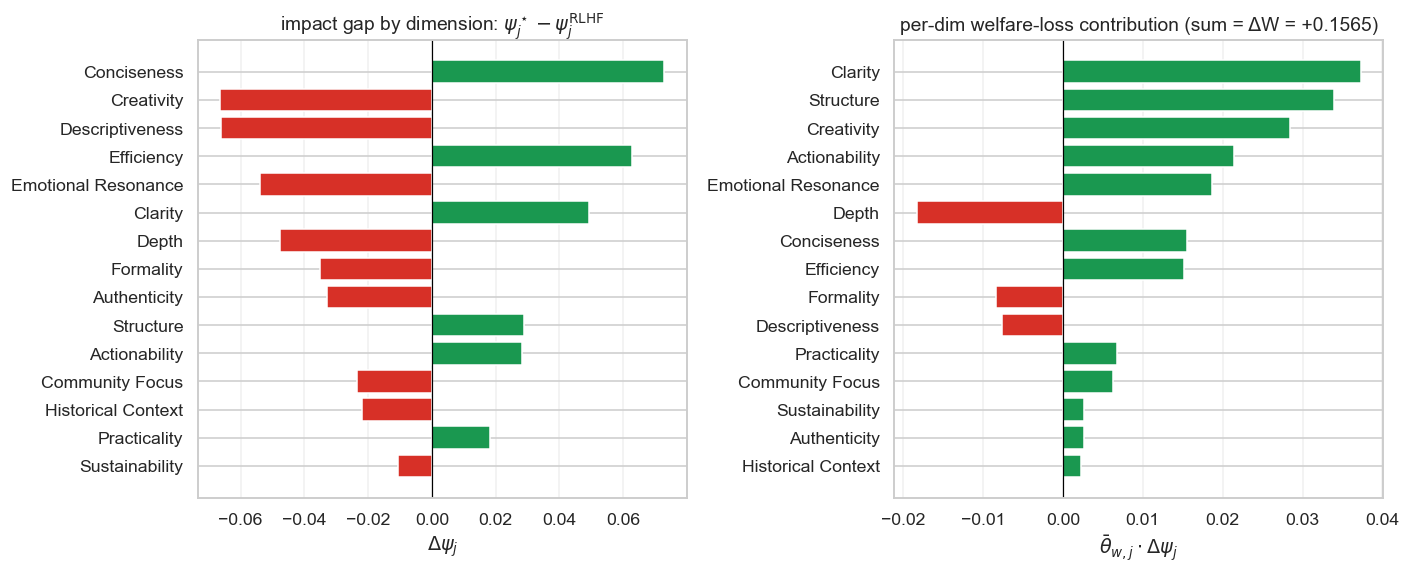

In [8]:
delta_psi = psi_star - psi_rlhf
W_star    = float(theta_bar @ psi_star)
W_rlhf    = float(theta_bar @ psi_rlhf)
Delta_W   = W_star - W_rlhf

print(f"W*       = {W_star:+.5f}")
print(f"W_RLHF   = {W_rlhf:+.5f}")
print(f"ΔW       = {Delta_W:+.5f}    relative loss = {Delta_W/W_star:.1%}")
print(f"INVARIANT  ΔW ≥ 0?  {Delta_W >= -1e-12}")

# Per-feature Δψ + welfare-loss contribution θ̄_w · Δψ_j (sums to ΔW)
contrib = theta_bar * delta_psi
fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))
order = np.argsort(np.abs(delta_psi))[::-1]
axes[0].barh(np.array(DIM_NAMES)[order][::-1], delta_psi[order][::-1],
             color=["#1a9850" if v >= 0 else "#d73027" for v in delta_psi[order][::-1]])
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_xlabel(r"$\Delta\psi_j$")
axes[0].set_title(r"impact gap by dimension: $\psi^\star_j - \psi^{\rm RLHF}_j$")
axes[0].grid(True, axis="x", alpha=0.3)

order2 = np.argsort(np.abs(contrib))[::-1]
axes[1].barh(np.array(DIM_NAMES)[order2][::-1], contrib[order2][::-1],
             color=["#1a9850" if v >= 0 else "#d73027" for v in contrib[order2][::-1]])
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_xlabel(r"$\bar\theta_{w,j} \cdot \Delta\psi_j$")
axes[1].set_title(fr"per-dim welfare-loss contribution (sum = ΔW = {contrib.sum():+.4f})")
axes[1].grid(True, axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

Σ_n w_n ΔW_n = +0.15648  (should equal ΔW = +0.15648, diff = 1.94e-16)
losers (ΔW_n > 0): 2090/2387    winners: 297/2387


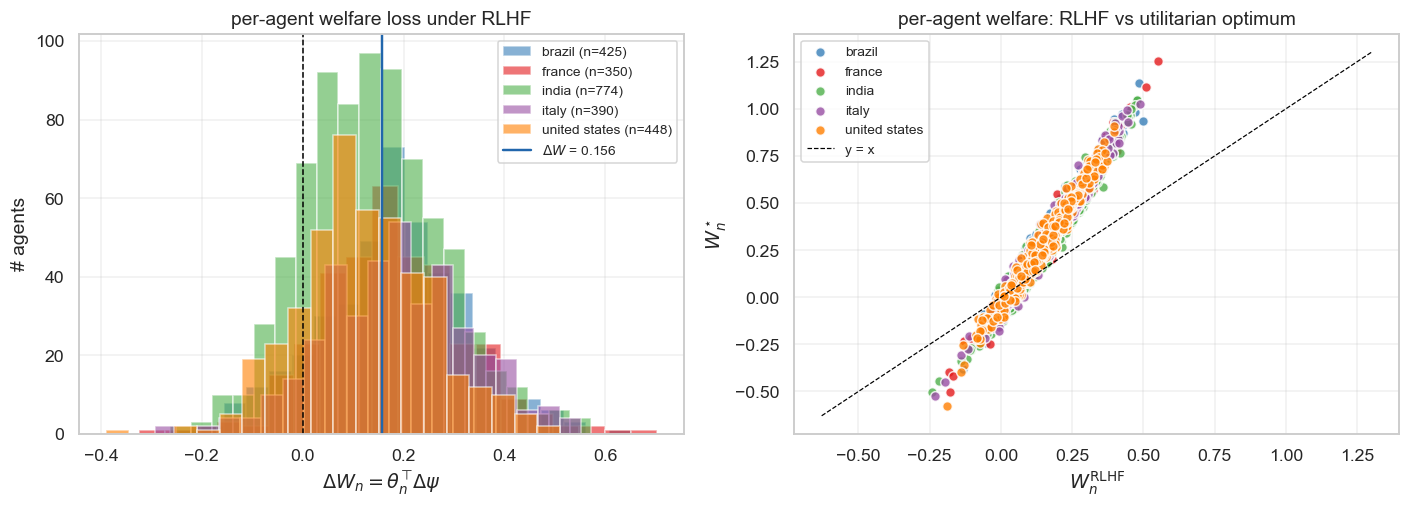

In [9]:
# Per-agent welfare gap ΔW_n = θ_n^T Δψ + winners/losers
DWn      = Theta @ delta_psi
Wn_star  = Theta @ psi_star
Wn_rlhf  = Theta @ psi_rlhf
print(f"Σ_n w_n ΔW_n = {weights@DWn:+.5f}  (should equal ΔW = {Delta_W:+.5f}, "
      f"diff = {abs(weights@DWn - Delta_W):.2e})")
print(f"losers (ΔW_n > 0): {(DWn>1e-9).sum()}/{N_AGENTS}    "
      f"winners: {(DWn<-1e-9).sum()}/{N_AGENTS}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
country_palette = {g: c for g, c in zip(sorted(np.unique(groups)), ["#377eb8", "#e41a1c", "#4daf4a", "#984ea3", "#ff7f00"])}
for g in sorted(np.unique(groups)):
    mask = groups == g
    axes[0].hist(DWn[mask], bins=20, alpha=0.6, label=f"{g} (n={mask.sum()})",
                 color=country_palette[g], edgecolor="white")
axes[0].axvline(0, color="black", lw=1.0, ls="--")
axes[0].axvline(Delta_W, color="#2166ac", lw=1.6, label=fr"$\Delta W$ = {Delta_W:.3f}")
axes[0].set_xlabel(r"$\Delta W_n = \theta_n^\top \Delta\psi$")
axes[0].set_ylabel("# agents"); axes[0].set_title("per-agent welfare loss under RLHF")
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

for g in sorted(np.unique(groups)):
    mask = groups == g
    axes[1].scatter(Wn_rlhf[mask], Wn_star[mask], s=40, alpha=0.8,
                    label=g, color=country_palette[g], edgecolor="white")
lim_lo = min(Wn_rlhf.min(), Wn_star.min()) - 0.05
lim_hi = max(Wn_rlhf.max(), Wn_star.max()) + 0.05
axes[1].plot([lim_lo, lim_hi], [lim_lo, lim_hi], color="black", ls="--", lw=0.8, label="y = x")
axes[1].set_xlabel(r"$W_n^{\rm RLHF}$"); axes[1].set_ylabel(r"$W_n^\star$")
axes[1].set_title("per-agent welfare: RLHF vs utilitarian optimum")
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [10]:
# §6.4 asymptotic version: separate direction from magnitude
psi_rlhf_inf = 0.5 * (alpha_train * np.sign(alpha_train @ theta_rlhf)[:, None]).mean(axis=0)
Delta_W_inf = W_star - float(theta_bar @ psi_rlhf_inf)
print(f"ΔW(β=1)  = {Delta_W:+.5f}    ({Delta_W/W_star:.1%} of W*)")
print(f"ΔW(β=∞)  = {Delta_W_inf:+.5f}    ({Delta_W_inf/W_star:.1%} of W*)")
print(f"  → directional misalignment fraction:    {Delta_W_inf/Delta_W:.0%}")
print(f"  → magnitude/regularization fraction:    {1-Delta_W_inf/Delta_W:.0%}")

ΔW(β=1)  = +0.15648    (47.5% of W*)
ΔW(β=∞)  = +0.01923    (5.8% of W*)
  → directional misalignment fraction:    12%
  → magnitude/regularization fraction:    88%


## §7. Participation externality $\Gamma_{n,m}$ via leave-one-out BTL

In [11]:
# 7.1 LOO refits — with on-disk cache so re-running this cell is instant after the first time.
# Loosened tolerance + joblib parallel: ~87 min sequential at tol=1e-8 → ~1-2 min on 8 cores.
# At C=1.0 the regularization dwarfs LBFGS's last few digits, so loose tol doesn't move Γ.
import time, os

CACHE = Path(f"theta_loo_N{N_AGENTS}_min{MIN_ROWS}.npz")

def _fit_loo(pid, person_id, alpha_train, y_train):
    keep = person_id != pid
    lr = LogisticRegression(fit_intercept=False, C=BTL_C, solver="lbfgs", max_iter=500, tol=1e-5)
    lr.fit(alpha_train[keep], y_train[keep])
    return lr.coef_.ravel()

theta_loo = None
if CACHE.exists():
    blob = np.load(CACHE, allow_pickle=True)
    if np.array_equal(blob["agent_ids"], agent_ids) and tuple(blob["alpha_shape"]) == alpha_train.shape:
        theta_loo = blob["theta_loo"]
        print(f"loaded cached LOO fits from {CACHE}  (delete the file to force recompute)")
    else:
        print(f"cache {CACHE} is stale (agent_ids or alpha_train changed) — recomputing")

if theta_loo is None:
    t0 = time.time()
    print(f"running {N_AGENTS} LOO BTL refits on {os.cpu_count()} cores ...")
    theta_loo = np.array(Parallel(n_jobs=-1, verbose=0)(
        delayed(_fit_loo)(pid, person_id, alpha_train, y_train) for pid in agent_ids
    ))
    print(f"  done in {time.time()-t0:.1f}s")
    np.savez_compressed(CACHE, theta_loo=theta_loo, agent_ids=agent_ids,
                        alpha_shape=np.array(alpha_train.shape))
    print(f"  cached → {CACHE} ({CACHE.stat().st_size/1024:.0f} KB)")

psi_loo = np.array([psi(theta_loo[i], alpha_train, 1.0) for i in range(N_AGENTS)])

# Convention: Γ_{n,m} = externality that Responsible Party n imposes on Externality Recipient m
#                    = θ_m^T · (ψ_full − ψ_{-n}). LOO removes n from the pool; the welfare
#                      change accrues to m (whose preferences θ_m we dot with the impact shift).
delta_n = psi_rlhf[None, :] - psi_loo                    # (N, k) — n varies (LOO'd agent)
Gamma   = delta_n @ Theta.T                              # (N, N): rows = Responsible Party n, cols = Externality Recipient m

print(f"Γ shape: {Gamma.shape}")
print(f"diagonal Γ_{{n,n}} (self-externality): mean={np.diag(Gamma).mean():+.5f}, "
      f"fraction positive={(np.diag(Gamma)>0).mean():.0%}")
print(f"|Γ| range: [{np.abs(Gamma).min():.5f}, {np.abs(Gamma).max():.5f}]")

loaded cached LOO fits from theta_loo_N2387_min20.npz  (delete the file to force recompute)
Γ shape: (2387, 2387)
diagonal Γ_{n,n} (self-externality): mean=+0.00007, fraction positive=99%
|Γ| range: [0.00000, 0.00145]


In [12]:
# 7.2 Heatmap, agents reordered by group (country)
order = np.lexsort((agent_ids, groups))
G_ord = Gamma[np.ix_(order, order)]
groups_ord = groups[order]
boundaries = [i for i in range(1, len(groups_ord)) if groups_ord[i] != groups_ord[i-1]]

# fig, ax = plt.subplots(figsize=(8.5, 7.2))
# vmax = float(np.max(np.abs(Gamma)))
# im = ax.imshow(G_ord, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
# cb = plt.colorbar(im, ax=ax, label=f"$\\Gamma_{{n,m}}$  (scale ±{vmax:.4f})")
#     ax.grid(False)
# ax.set_xlabel("Externality Recipient (m)"); ax.set_ylabel("Responsible Party (n)")
# ax.set_xticks([]); ax.set_yticks([])
# for b in boundaries:
#     ax.axhline(b - 0.5, color="black", lw=1.4)
#     ax.axvline(b - 0.5, color="black", lw=1.4)
# for g in sorted(np.unique(groups)):
#     pos = np.where(groups_ord == g)[0]
#     mid = (pos[0] + pos[-1]) / 2
#     n = len(pos)
#     ax.annotate(f"{g} (n={n})", xy=(mid, -1.5), fontsize=11, fontweight="bold",
#                 ha="center", va="bottom", annotation_clip=False)
#     ax.annotate(g, xy=(-1.5, mid), fontsize=11, fontweight="bold",
#                 ha="right", va="center", rotation=90, annotation_clip=False)
# ax.set_title(r"Participation externality $\Gamma_{n,m}$ grouped by country")
# plt.tight_layout(); plt.show()

In [13]:
# 7.3 Mean Γ by group pair (Country x Country) -- Γ_{n,m} = n imposes on m
groups_disp = np.array([g.title() if isinstance(g, str) else g for g in groups])
uniq = sorted(np.unique(groups_disp))
G_summary = np.zeros((len(uniq), len(uniq)))
# for i, gn in enumerate(uniq):
#     for j, gm in enumerate(uniq):
#         block = Gamma[np.ix_(groups_disp == gn, groups_disp == gm)]
#         if i == j:
#             od = block[~np.eye(block.shape[0], dtype=bool)]
#             G_summary[i, j] = od.mean() if od.size else 0.0
#         else:
#             G_summary[i, j] = block.mean()

# fig, ax = plt.subplots(figsize=(5.6, 4.8))
# vs = float(np.max(np.abs(G_summary)))
# im2 = ax.imshow(G_summary, cmap="RdBu_r", vmin=-vs, vmax=vs)
# ax.grid(False)
# cb = plt.colorbar(im2, ax=ax, label=f"Mean $\\Gamma$ in block  (panel scale +/-{vs:.4f})")
# ax.set_xticks(range(len(uniq))); ax.set_xticklabels(uniq, fontsize=11)
# ax.set_yticks(range(len(uniq))); ax.set_yticklabels(uniq, fontsize=11)
# ax.set_xlabel("Externality Recipient (Country)")
# ax.set_ylabel("Responsible Party (Country)")
# ax.set_title("Mean externality by country pair\n(Diagonal: within-country, excl. own benefit)\n"
#              "Red = Responsible Party helps Recipient, blue = hurts")
# plt.tight_layout(); plt.show()

# print("\nPer-country mean Γ (rows = Responsible Party, cols = Externality Recipient):")
# print(pd.DataFrame(G_summary, index=uniq, columns=uniq).round(5).to_string())
# print(f"\nWITHIN-country avg:  {np.diag(G_summary).mean():+.5f}")
# off_mask = ~np.eye(len(uniq), dtype=bool)
# print(f"ACROSS-country avg:  {G_summary[off_mask].mean():+.5f}")

### §7.4 Externality patterns by demographic axis

Same `Γ` matrix, re-sliced by every demographic in the dataset. Cheap — no refits required, the slow LOO step is already done.

Each panel shows the within-vs-across-group block average for one demographic axis. The **within − across** number in the title is the headline: positive means same-group annotators help each other *more* than across-group annotators (anonymous RLHF distributes externalities along that demographic line); the largest |within − across| identifies the axis along which anonymous aggregation distorts most.

Sparse columns are collapsed: 7-way political → Left/Center-None/Right, education → post-sec-grad / grad-degree / Other, ethnicity → White / Indo-Aryan / Other.

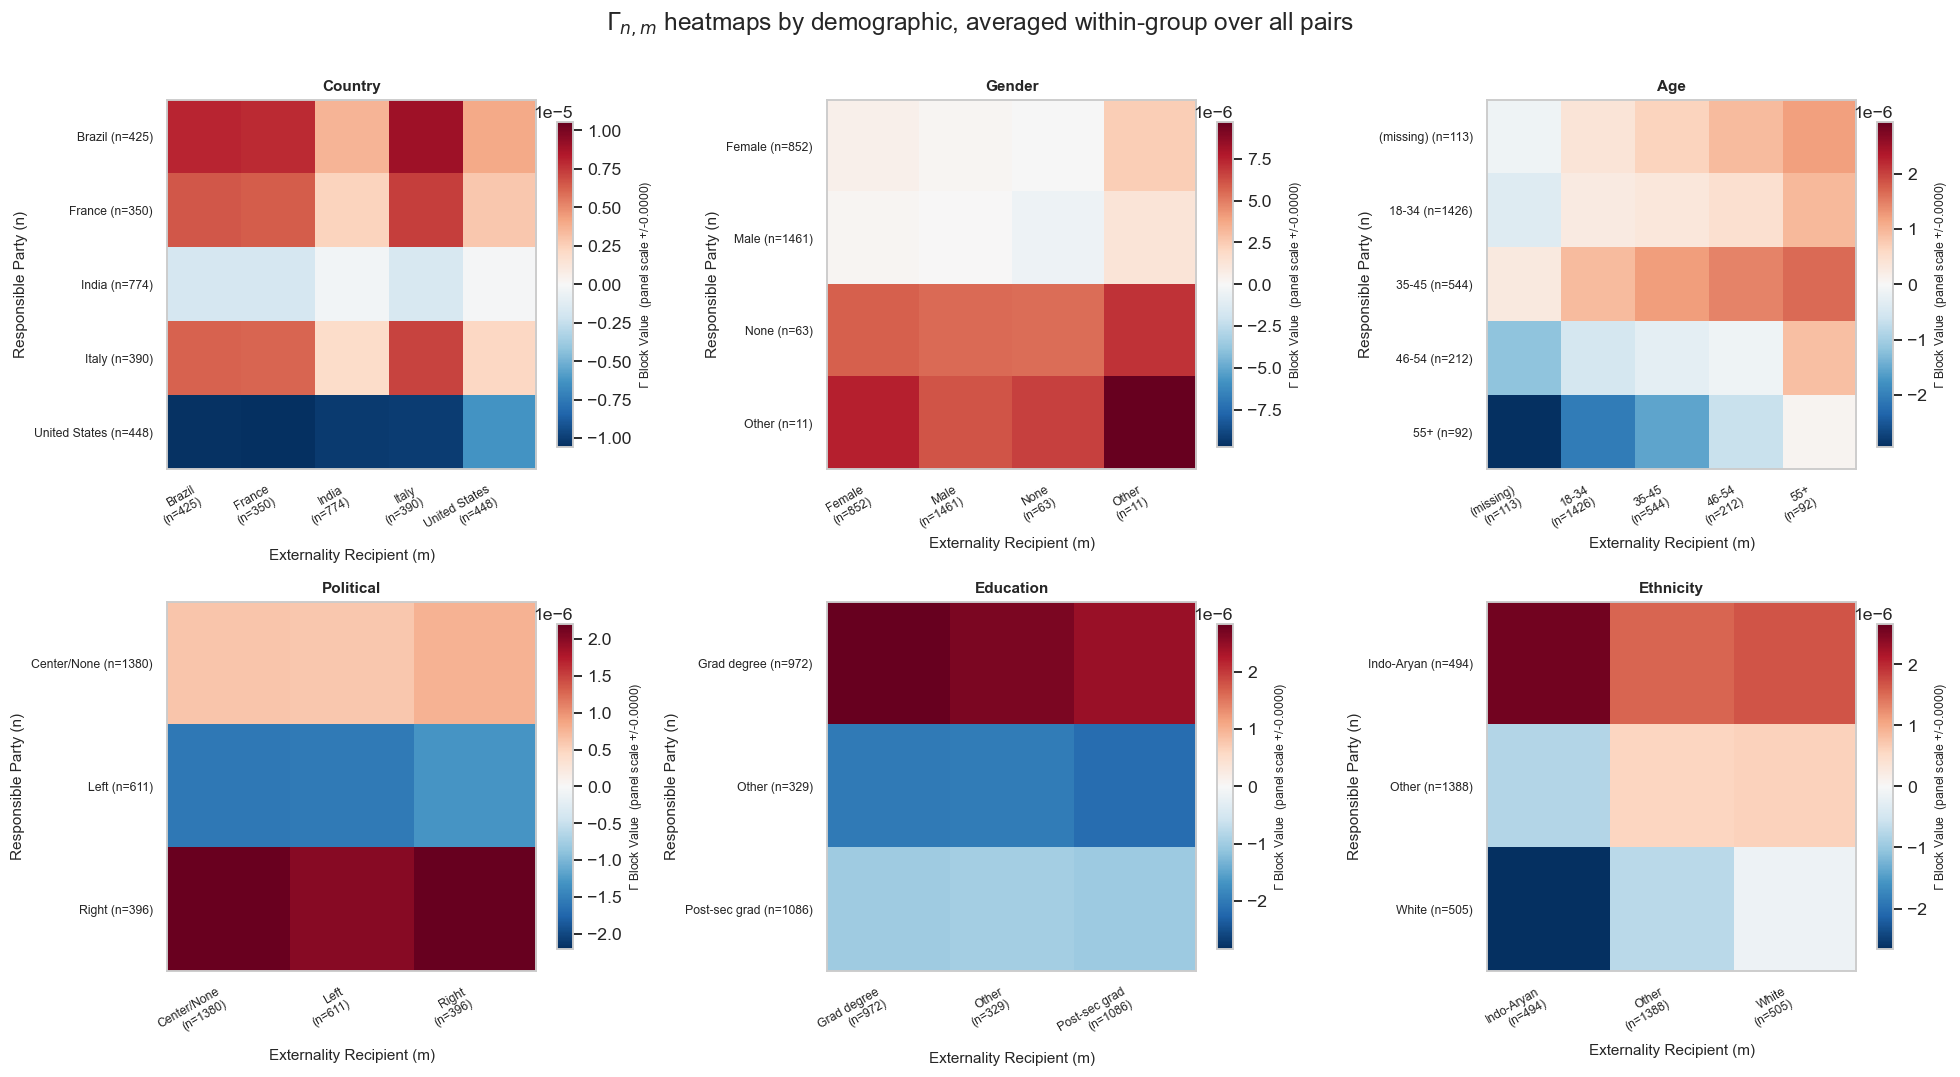

=== mean per-agent welfare loss ΔW_n by demographic ===

— Country —
        group   n  mean_ΔW_n  loser_pct
        Italy 390    0.18574    0.91282
       Brazil 425    0.17999    0.88941
       France 350    0.17812    0.92000
        India 774    0.13742    0.84625
United States 448    0.12476    0.84598

— Gender —
 group    n  mean_ΔW_n  loser_pct
 Other   11    0.17185    1.00000
  None   63    0.16009    0.93651
Female  852    0.15870    0.88615
  Male 1461    0.15492    0.86585

— Age —
group    n  mean_ΔW_n  loser_pct
35-45  544    0.16365    0.86949
46-54  212    0.15948    0.88679
18-34 1426    0.15440    0.87377
  55+   92    0.15375    0.89130

— Political —
      group    n  mean_ΔW_n  loser_pct
Center/None 1380    0.16040    0.87754
      Right  396    0.15527    0.89141
       Left  611    0.14843    0.86088

— Education —
        group    n  mean_ΔW_n  loser_pct
  Grad degree  972    0.16476    0.88889
        Other  329    0.15201    0.87234
Post-sec grad 1086    0.15

In [14]:
# §7.4 — Single-demographic externality views.
# Same Γ matrix, re-sliced by each demographic axis. No refits required.

MIN_CELL_N = 5    # drop groups smaller than this from any panel — too noisy

# 1) Per-agent demographic frame, indexed in the same order as Theta / Gamma.
ann_demo = sub.drop_duplicates("annotator_id").set_index("annotator_id")
demo_df = ann_demo.loc[agent_ids][[
    "annotator_country", "annotator_gender", "annotator_age",
    "annotator_political", "annotator_education_level", "annotator_ethnicity",
]].copy()
# Title-case the lower-case raw values for paper-quality labels.
demo_df["annotator_country"] = demo_df["annotator_country"].astype(str).str.title()
demo_df["annotator_gender"]  = demo_df["annotator_gender"].astype(str).str.title()

def _coll_pol(s):
    if s in ("Very left-leaning", "Somewhat left-leaning"):  return "Left"
    if s in ("Somewhat right-leaning", "Very right-leaning"): return "Right"
    return "Center/None"
def _coll_edu(s):
    if s == "Post-secondary graduate":            return "Post-sec grad"
    if s == "Some or complete graduate degree":   return "Grad degree"
    return "Other"
def _coll_eth(s):
    return s if s in ("White", "Indo-Aryan") else "Other"

demo_df["political_3"] = demo_df["annotator_political"].map(_coll_pol)
demo_df["education_3"] = demo_df["annotator_education_level"].map(_coll_edu)
demo_df["ethnicity_3"] = demo_df["annotator_ethnicity"].map(_coll_eth)

# Country abbreviations keep cross-demographic labels readable later.
country_abbr = {"United States": "US", "India": "IN", "Brazil": "BR",
                "France": "FR", "Italy": "IT"}
demo_df["ctry"] = demo_df["annotator_country"].map(country_abbr)

# 2) Helper: drop sparse buckets, build (k×k) summary on Γ, render heatmap.
def gamma_summary(group_arr, min_n=MIN_CELL_N):
    # Drop missing values — None/NaN can't be compared during sort or grouped meaningfully.
    group_arr = pd.Series(group_arr).where(lambda s: s.notna(), None).fillna("(missing)").to_numpy()
    counts = pd.Series(group_arr).value_counts()
    keep   = set(counts[counts >= min_n].index)
    mask   = np.array([g in keep for g in group_arr])
    if mask.sum() < 2:
        return None
    g_arr = group_arr[mask]
    G_sub = Gamma[np.ix_(mask, mask)]
    uniq  = sorted(np.unique(g_arr).tolist())
    G     = np.zeros((len(uniq), len(uniq)))
    for i, gn in enumerate(uniq):
        for j, gm in enumerate(uniq):
            block = G_sub[np.ix_(g_arr == gn, g_arr == gm)]
            if i == j:
                od = block[~np.eye(block.shape[0], dtype=bool)]
                G[i, j] = od.mean() if od.size else 0.0
            else:
                G[i, j] = block.mean()
    return G, uniq, {g: int((g_arr == g).sum()) for g in uniq}, int((~mask).sum())

def plot_gamma_heatmap(ax, group_arr, label, fs_lab=8):
    res = gamma_summary(group_arr)
    if res is None:
        ax.set_visible(False); return None
    G, uniq, counts, n_drop = res
    vs = float(np.max(np.abs(G))) or 1e-12
    im = ax.imshow(G, cmap="RdBu_r", vmin=-vs, vmax=vs)
    ax.set_xticks(range(len(uniq)))
    ax.set_xticklabels([f"{g}\n(n={counts[g]})" for g in uniq],
                       fontsize=fs_lab, rotation=30, ha="right")
    ax.set_yticks(range(len(uniq)))
    ax.set_yticklabels([f"{g} (n={counts[g]})" for g in uniq], fontsize=fs_lab)
    ax.set_xlabel("Externality Recipient (m)", fontsize=10)
    ax.set_ylabel("Responsible Party (n)", fontsize=10)
    ax.grid(False)
    cb = plt.colorbar(im, ax=ax, fraction=0.04)
    cb.set_label(f"$\\Gamma$ Block Value  (panel scale +/-{vs:.4f})", fontsize=8)
    within = float(np.diag(G).mean())
    across = float(G[~np.eye(len(uniq), dtype=bool)].mean()) if len(uniq) > 1 else np.nan
    title  = f"{label}"
    if n_drop: title += f"\ndropped {n_drop} agents in cells with n<{MIN_CELL_N}"
    ax.set_title(title, fontsize=10, fontweight="bold")
    return {"axis": label, "n_groups": len(uniq),
            "within": within, "across": across, "diff": within - across,
            "dropped": n_drop}

# 3) Single-demographic heatmaps in a 2×3 grid.
SINGLE = [
    ("annotator_country", "Country"),
    ("annotator_gender",  "Gender"),
    ("annotator_age",     "Age"),
    ("political_3",       "Political"),
    ("education_3",       "Education"),
    ("ethnicity_3",       "Ethnicity"),
]
fig, axes = plt.subplots(2, 3, figsize=(18, 11.5))
single_rows = [plot_gamma_heatmap(ax, demo_df[c].to_numpy(), l)
               for ax, (c, l) in zip(axes.flat, SINGLE)]
fig.suptitle(r"$\Gamma_{n,m}$ heatmaps by demographic, averaged within-group over all pairs",
             fontsize=16, y=0.85)
plt.tight_layout(rect=[0, 0, 1, 0.85]); plt.show()

# 4) Per-group mean ΔW_n: which groups bear more of the welfare loss.
DWn = Theta @ delta_psi
print("=== mean per-agent welfare loss ΔW_n by demographic ===")
for col, label in SINGLE:
    g_arr = demo_df[col].to_numpy()
    rows = []
    g_vals = [v for v in pd.unique(g_arr).tolist() if v is not None and not (isinstance(v, float) and np.isnan(v))]
    for g in sorted(g_vals):
        m = g_arr == g
        if m.sum() < MIN_CELL_N: continue
        rows.append({"group": g, "n": int(m.sum()),
                     "mean_ΔW_n": float(DWn[m].mean()),
                     "loser_pct": float((DWn[m] > 1e-9).mean())})
    print(f"\n— {label} —")
    print(pd.DataFrame(rows).sort_values("mean_ΔW_n", ascending=False).round(5).to_string(index=False))

print("\n=== single-axis Γ summary, sorted by |within − across| ===")
print(pd.DataFrame([r for r in single_rows if r])
      .sort_values("diff", key=abs, ascending=False).round(6).to_string(index=False))

### §7.4a Per-person breakdown — un-averaged Γ heatmaps (sampled)

Same six demographic axes as §7.4, but instead of averaging Γ within each group block we show the raw per-person Γ matrix for a **stratified sample of N_SAMPLE annotators** (proportional to group size, with a per-group floor so small groups stay visible). Reveals within-group heterogeneity that the block average flattens, without rendering a 2,387 × 2,387 matrix.


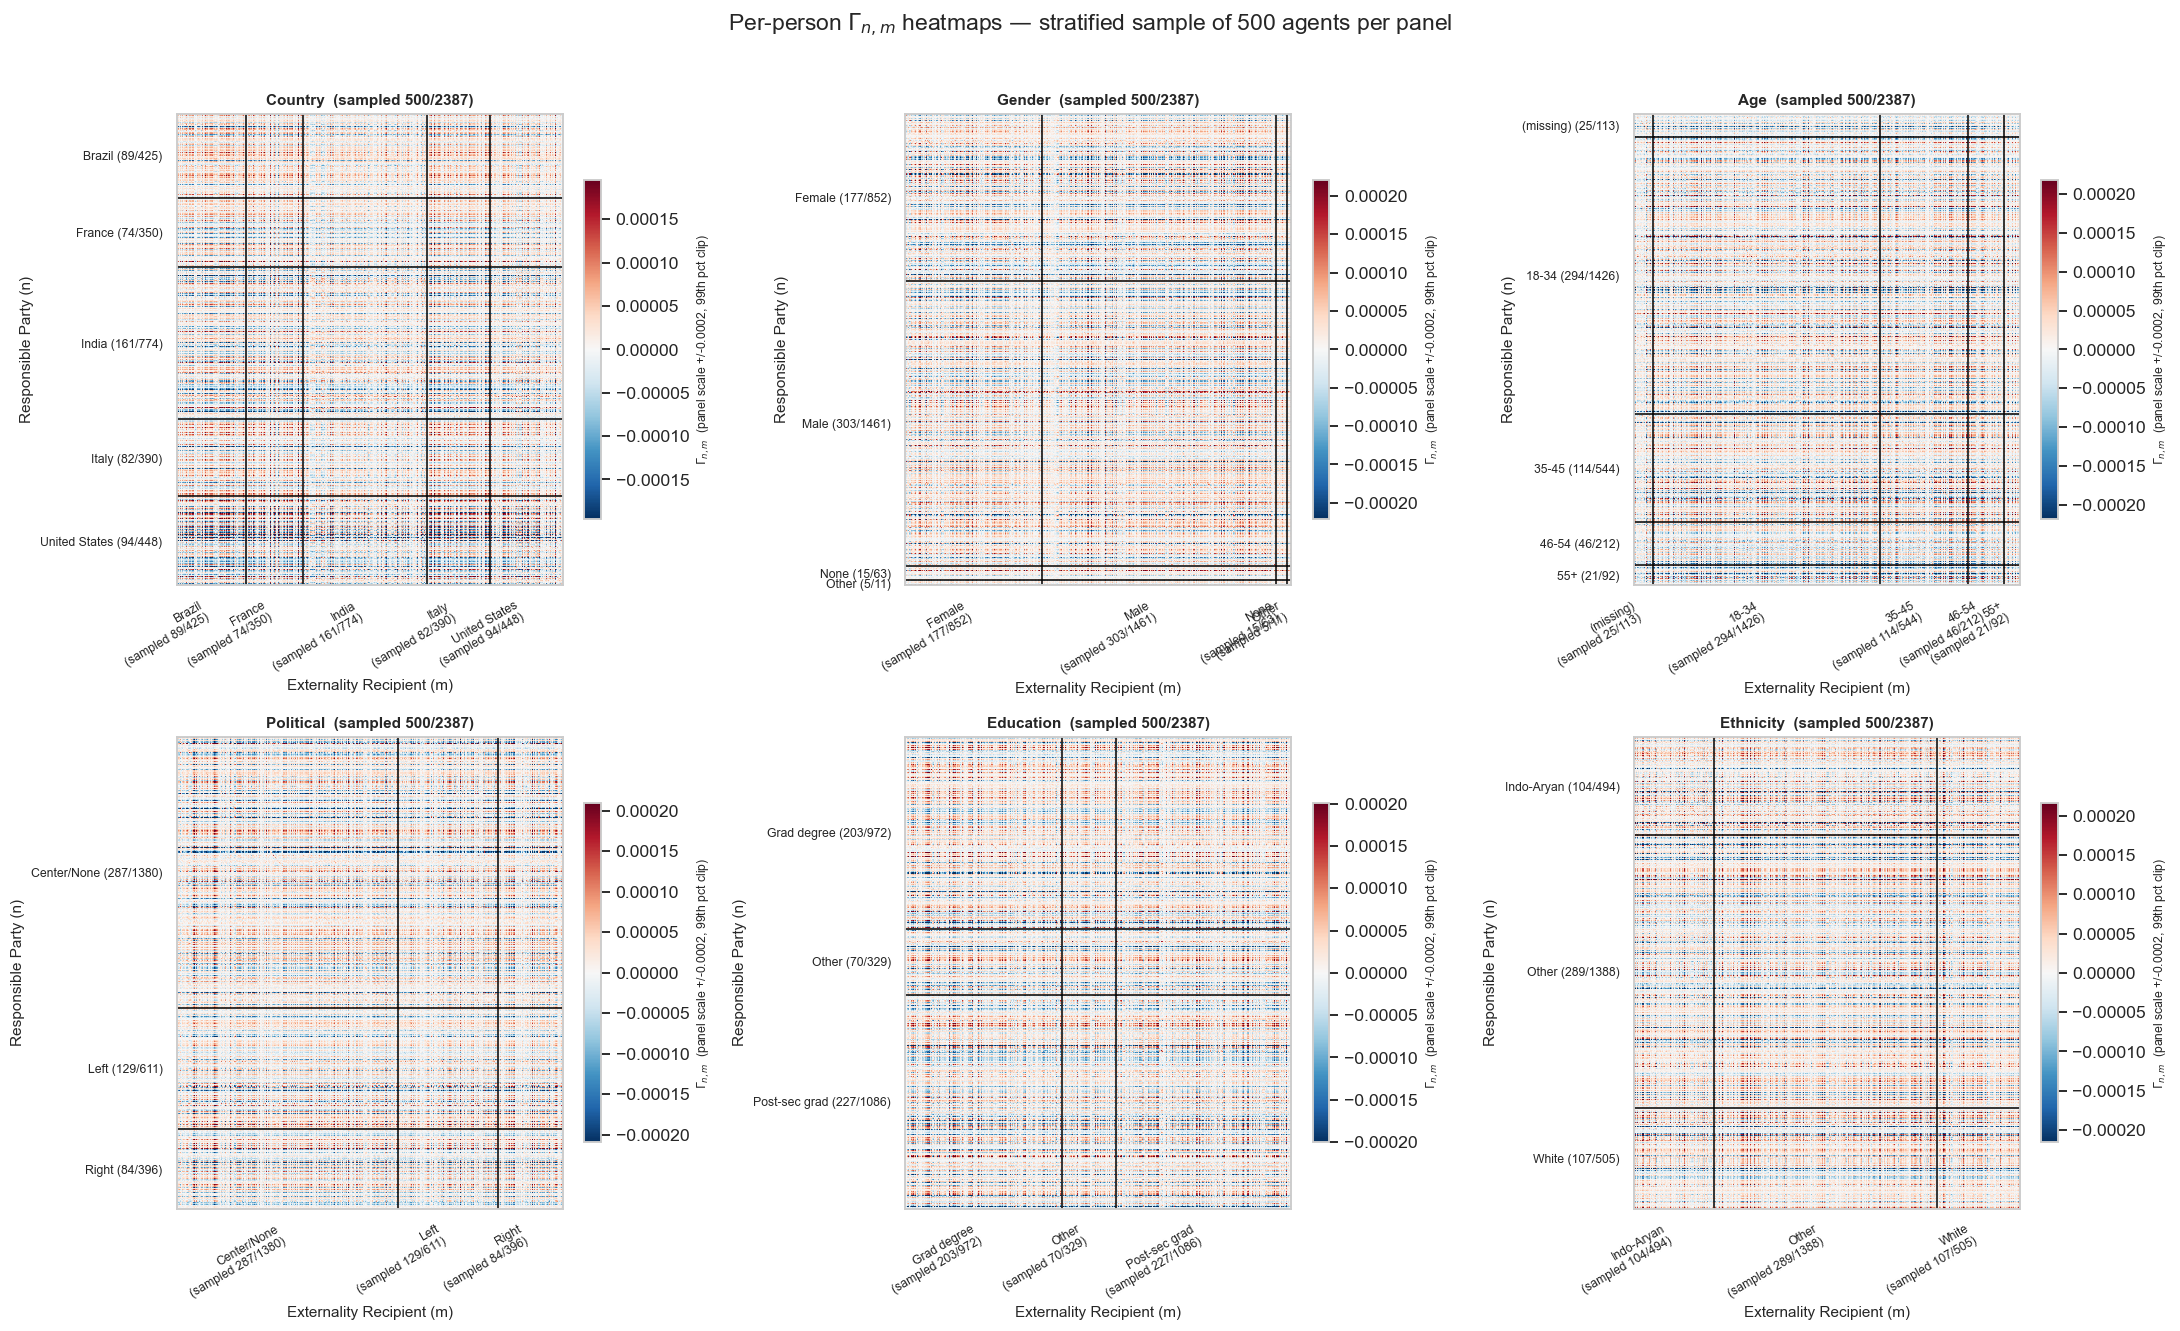

In [15]:
# §7.4a — Per-person Γ heatmaps for a stratified sample.
N_SAMPLE   = 500   # total agents drawn across all kept groups
PER_GROUP_MIN = 3  # floor so small groups stay visible

rng = np.random.default_rng(0)

def _stratified_sample(g_arr, keep_groups, n_total, per_group_min, rng):
    counts = {g: int((g_arr == g).sum()) for g in keep_groups}
    n_kept = sum(counts.values())
    floor  = {g: min(per_group_min, counts[g]) for g in keep_groups}
    rem    = max(0, n_total - sum(floor.values()))
    # Distribute remainder proportional to (group size - floor allocation).
    weights = np.array([max(0, counts[g] - floor[g]) for g in keep_groups], float)
    extra   = (weights / weights.sum() * rem).round().astype(int) if weights.sum() > 0 else np.zeros(len(keep_groups), int)
    alloc   = {g: floor[g] + e for g, e in zip(keep_groups, extra)}
    # Adjust for rounding so total ≈ n_total
    while sum(alloc.values()) > n_total:
        g = max(keep_groups, key=lambda g: alloc[g] - floor[g])
        alloc[g] -= 1
    while sum(alloc.values()) < n_total and any(alloc[g] < counts[g] for g in keep_groups):
        g = max(keep_groups, key=lambda g: counts[g] - alloc[g])
        alloc[g] += 1
    picks = []
    for g in keep_groups:
        idx_g = np.where(g_arr == g)[0]
        picks.append(rng.choice(idx_g, size=alloc[g], replace=False))
    return np.concatenate(picks), alloc

def plot_gamma_per_person(ax, group_arr, label, min_n=MIN_CELL_N,
                          n_total=N_SAMPLE, per_group_min=PER_GROUP_MIN):
    g_arr = pd.Series(group_arr).where(lambda s: s.notna(), None).fillna("(missing)").to_numpy()
    counts = pd.Series(g_arr).value_counts()
    keep_groups = sorted([g for g in counts.index if counts[g] >= min_n])
    if len(keep_groups) < 2:
        ax.set_visible(False); return None

    keep_mask = np.array([g in set(keep_groups) for g in g_arr])
    g_kept = g_arr[keep_mask]
    keep_idx = np.where(keep_mask)[0]
    n_drop = int((~keep_mask).sum())

    sample_local, alloc = _stratified_sample(g_kept, keep_groups, n_total, per_group_min, rng)
    sample_global = keep_idx[sample_local]
    g_samp = g_kept[sample_local]

    # Sort sampled agents by group label.
    order = np.concatenate([np.where(g_samp == g)[0] for g in keep_groups])
    sample_sorted = sample_global[order]
    g_sorted = g_samp[order]
    G_plot = Gamma[np.ix_(sample_sorted, sample_sorted)]

    vs = float(np.percentile(np.abs(G_plot), 99)) or 1e-12   # 99th-pct clip
    im = ax.imshow(G_plot, cmap="RdBu_r", vmin=-vs, vmax=vs,
                   aspect="auto", interpolation="nearest")

    # Group boundaries.
    boundaries, midpoints = [], []
    cum = 0
    for g in keep_groups:
        n_g = int((g_sorted == g).sum())
        midpoints.append(cum + n_g / 2 - 0.5)
        cum += n_g
        boundaries.append(cum - 0.5)
    for b in boundaries[:-1]:
        ax.axhline(b, color="black", lw=1.0)
        ax.axvline(b, color="black", lw=1.0)

    ax.set_xticks(midpoints)
    ax.set_xticklabels([f"{g}\n(sampled {alloc[g]}/{counts[g]})" for g in keep_groups],
                       fontsize=8, rotation=30, ha="right")
    ax.set_yticks(midpoints)
    ax.set_yticklabels([f"{g} ({alloc[g]}/{counts[g]})" for g in keep_groups], fontsize=8)
    ax.set_xlabel("Externality Recipient (m)", fontsize=10)
    ax.set_ylabel("Responsible Party (n)", fontsize=10)
    ax.grid(False)
    cb = plt.colorbar(im, ax=ax, fraction=0.04)
    cb.set_label(f"$\\Gamma_{{n,m}}$  (panel scale +/-{vs:.4f}, 99th pct clip)", fontsize=8)

    title = f"{label}  (sampled {len(sample_sorted)}/{int(keep_mask.sum())})"
    if n_drop: title += f"\ndropped {n_drop} agents in cells with n<{min_n}"
    ax.set_title(title, fontsize=10, fontweight="bold")
    return label

fig, axes = plt.subplots(2, 3, figsize=(20, 13))
for ax, (col, lab) in zip(axes.flat, SINGLE):
    plot_gamma_per_person(ax, demo_df[col].to_numpy(), lab)
fig.suptitle(rf"Per-person $\Gamma_{{n,m}}$ heatmaps — stratified sample of {N_SAMPLE} agents per panel",
             fontsize=15, y=0.93)
plt.tight_layout(rect=[0, 0, 1, 0.92]); plt.show()


### §7.4b Side-by-side: per-person Γ vs per-group averaged Γ

For each demographic axis, the **left** panel shows the per-person Γ matrix on a stratified sample of agents (same view as §7.4a), and the **right** panel shows the within/across-group block average (same view as §7.4). Direct visual comparison of how much within-group heterogeneity the block average flattens.


In [16]:
# §7.4b — Side-by-side per-person vs per-group averaged Γ for each demographic axis.
# Color gradient uses a power transform so values just away from 0 already show color.
GAMMA_POW = 0.45   # <1 makes mid-range values more colorful; 1.0 = linear

def _pow_intense(M, gamma_pow=GAMMA_POW):
    """sign-preserving |x|^gamma rescale, returns (M_transformed, raw_vs)."""
    vs = float(np.percentile(np.abs(M), 99)) or 1e-12
    if gamma_pow == 1.0:
        return M, vs
    M_t = np.sign(M) * np.power(np.abs(M) / vs, gamma_pow) * vs
    return M_t, vs

def _plot_per_person_pow(ax, group_arr, label, min_n=MIN_CELL_N,
                         n_total=N_SAMPLE, per_group_min=PER_GROUP_MIN,
                         gamma_pow=GAMMA_POW):
    g_arr = pd.Series(group_arr).where(lambda s: s.notna(), None).fillna("(missing)").to_numpy()
    counts = pd.Series(g_arr).value_counts()
    keep_groups = sorted([g for g in counts.index if counts[g] >= min_n])
    if len(keep_groups) < 2:
        ax.set_visible(False); return None
    keep_mask = np.array([g in set(keep_groups) for g in g_arr])
    g_kept = g_arr[keep_mask]
    keep_idx = np.where(keep_mask)[0]
    sample_local, alloc = _stratified_sample(g_kept, keep_groups, n_total, per_group_min, rng)
    sample_global = keep_idx[sample_local]
    g_samp = g_kept[sample_local]
    order = np.concatenate([np.where(g_samp == g)[0] for g in keep_groups])
    sample_sorted = sample_global[order]
    g_sorted = g_samp[order]
    G_plot = Gamma[np.ix_(sample_sorted, sample_sorted)]
    G_t, vs = _pow_intense(G_plot, gamma_pow)
    im = ax.imshow(G_t, cmap="RdBu_r", vmin=-vs, vmax=vs,
                   aspect="auto", interpolation="nearest")
    boundaries, midpoints = [], []
    cum = 0
    for g in keep_groups:
        n_g = int((g_sorted == g).sum())
        midpoints.append(cum + n_g / 2 - 0.5)
        cum += n_g
        boundaries.append(cum - 0.5)
    for b in boundaries[:-1]:
        ax.axhline(b, color="black", lw=1.0)
        ax.axvline(b, color="black", lw=1.0)
    ax.set_xticks(midpoints)
    ax.set_xticklabels([f"{g}\n(sampled {alloc[g]}/{counts[g]})" for g in keep_groups],
                       fontsize=8, rotation=30, ha="right")
    ax.set_yticks(midpoints)
    ax.set_yticklabels([f"{g} ({alloc[g]}/{counts[g]})" for g in keep_groups], fontsize=8)
    ax.set_xlabel("Externality Recipient (m)", fontsize=10)
    ax.set_ylabel("Responsible Party (n)", fontsize=10)
    ax.grid(False)
    cb = plt.colorbar(im, ax=ax, fraction=0.04)
    cb.set_label(rf"$\\Gamma_{{n,m}}$  (panel +/-{vs:.4f}, $|x|^{{{gamma_pow}}}$ shading)", fontsize=8)
    ax.set_title(f"{label} — Per-person", fontsize=10, fontweight="bold")

def _plot_group_avg_pow(ax, group_arr, label, gamma_pow=GAMMA_POW):
    res = gamma_summary(group_arr)
    if res is None:
        ax.set_visible(False); return None
    G, uniq, counts, n_drop = res
    G_t, vs = _pow_intense(G, gamma_pow)
    im = ax.imshow(G_t, cmap="RdBu_r", vmin=-vs, vmax=vs)
    ax.set_xticks(range(len(uniq)))
    ax.set_xticklabels([f"{g}\n(n={counts[g]})" for g in uniq],
                       fontsize=8, rotation=30, ha="right")
    ax.set_yticks(range(len(uniq)))
    ax.set_yticklabels([f"{g} (n={counts[g]})" for g in uniq], fontsize=8)
    ax.set_xlabel("Externality Recipient (m)", fontsize=10)
    ax.set_ylabel("Responsible Party (n)", fontsize=10)
    ax.grid(False)
    cb = plt.colorbar(im, ax=ax, fraction=0.04)
    cb.set_label(rf"$\\Gamma$ block (panel +/-{vs:.4f}, $|x|^{{{gamma_pow}}}$ shading)", fontsize=8)
    title = f"{label} — Group-averaged"
    if n_drop: title += f"\ndropped {n_drop} agents in cells with n<{MIN_CELL_N}"
    ax.set_title(title, fontsize=10, fontweight="bold")

fig, axes = plt.subplots(len(SINGLE), 2, figsize=(16, 5.5 * len(SINGLE)))
for row, (col, lab) in enumerate(SINGLE):
    _plot_per_person_pow(axes[row, 0], demo_df[col].to_numpy(), lab)
    _plot_group_avg_pow (axes[row, 1], demo_df[col].to_numpy(), lab)
fig.suptitle(rf"Per-person (left) vs Group-averaged (right) $\Gamma_{{n,m}}$  —  $|x|^{{{GAMMA_POW}}}$ color shading, sample of {N_SAMPLE}",
             fontsize=15, y=1.0)
plt.tight_layout(rect=[0, 0, 1, 0.99]); plt.show()


ValueError: 
\\Gamma_{n,m}
^
ParseFatalException: Unknown symbol: \, found '\'  (at char 0), (line:1, col:1)

Error in callback <function _draw_all_if_interactive at 0x136f42440> (for post_execute):


ValueError: 
\\Gamma_{n,m}
^
ParseFatalException: Unknown symbol: \, found '\'  (at char 0), (line:1, col:1)

ValueError: 
\\Gamma_{n,m}
^
ParseFatalException: Unknown symbol: \, found '\'  (at char 0), (line:1, col:1)

<Figure size 1760x3630 with 24 Axes>

### §7.5 Cross-demographic externality views

Now intersect demographics: e.g., "left-leaning Americans", "Indian women aged 35-45". Each cross-axis is the Cartesian product of two single demographics. Same `Γ`, finer slicing.

Cells with `n < MIN_CELL_N` (default 5) are dropped from each panel — at the intersection of two demographic axes, sample sizes get thin fast, and a within-group estimate at n=1 is meaningless. The bottom of the cell prints (a) a unified summary across all single + cross axes ranked by `|within − across|` and (b) the top group→group pairs from cross-demographic axes (the actual answer to "which sub-population most helps/hurts which other sub-population").

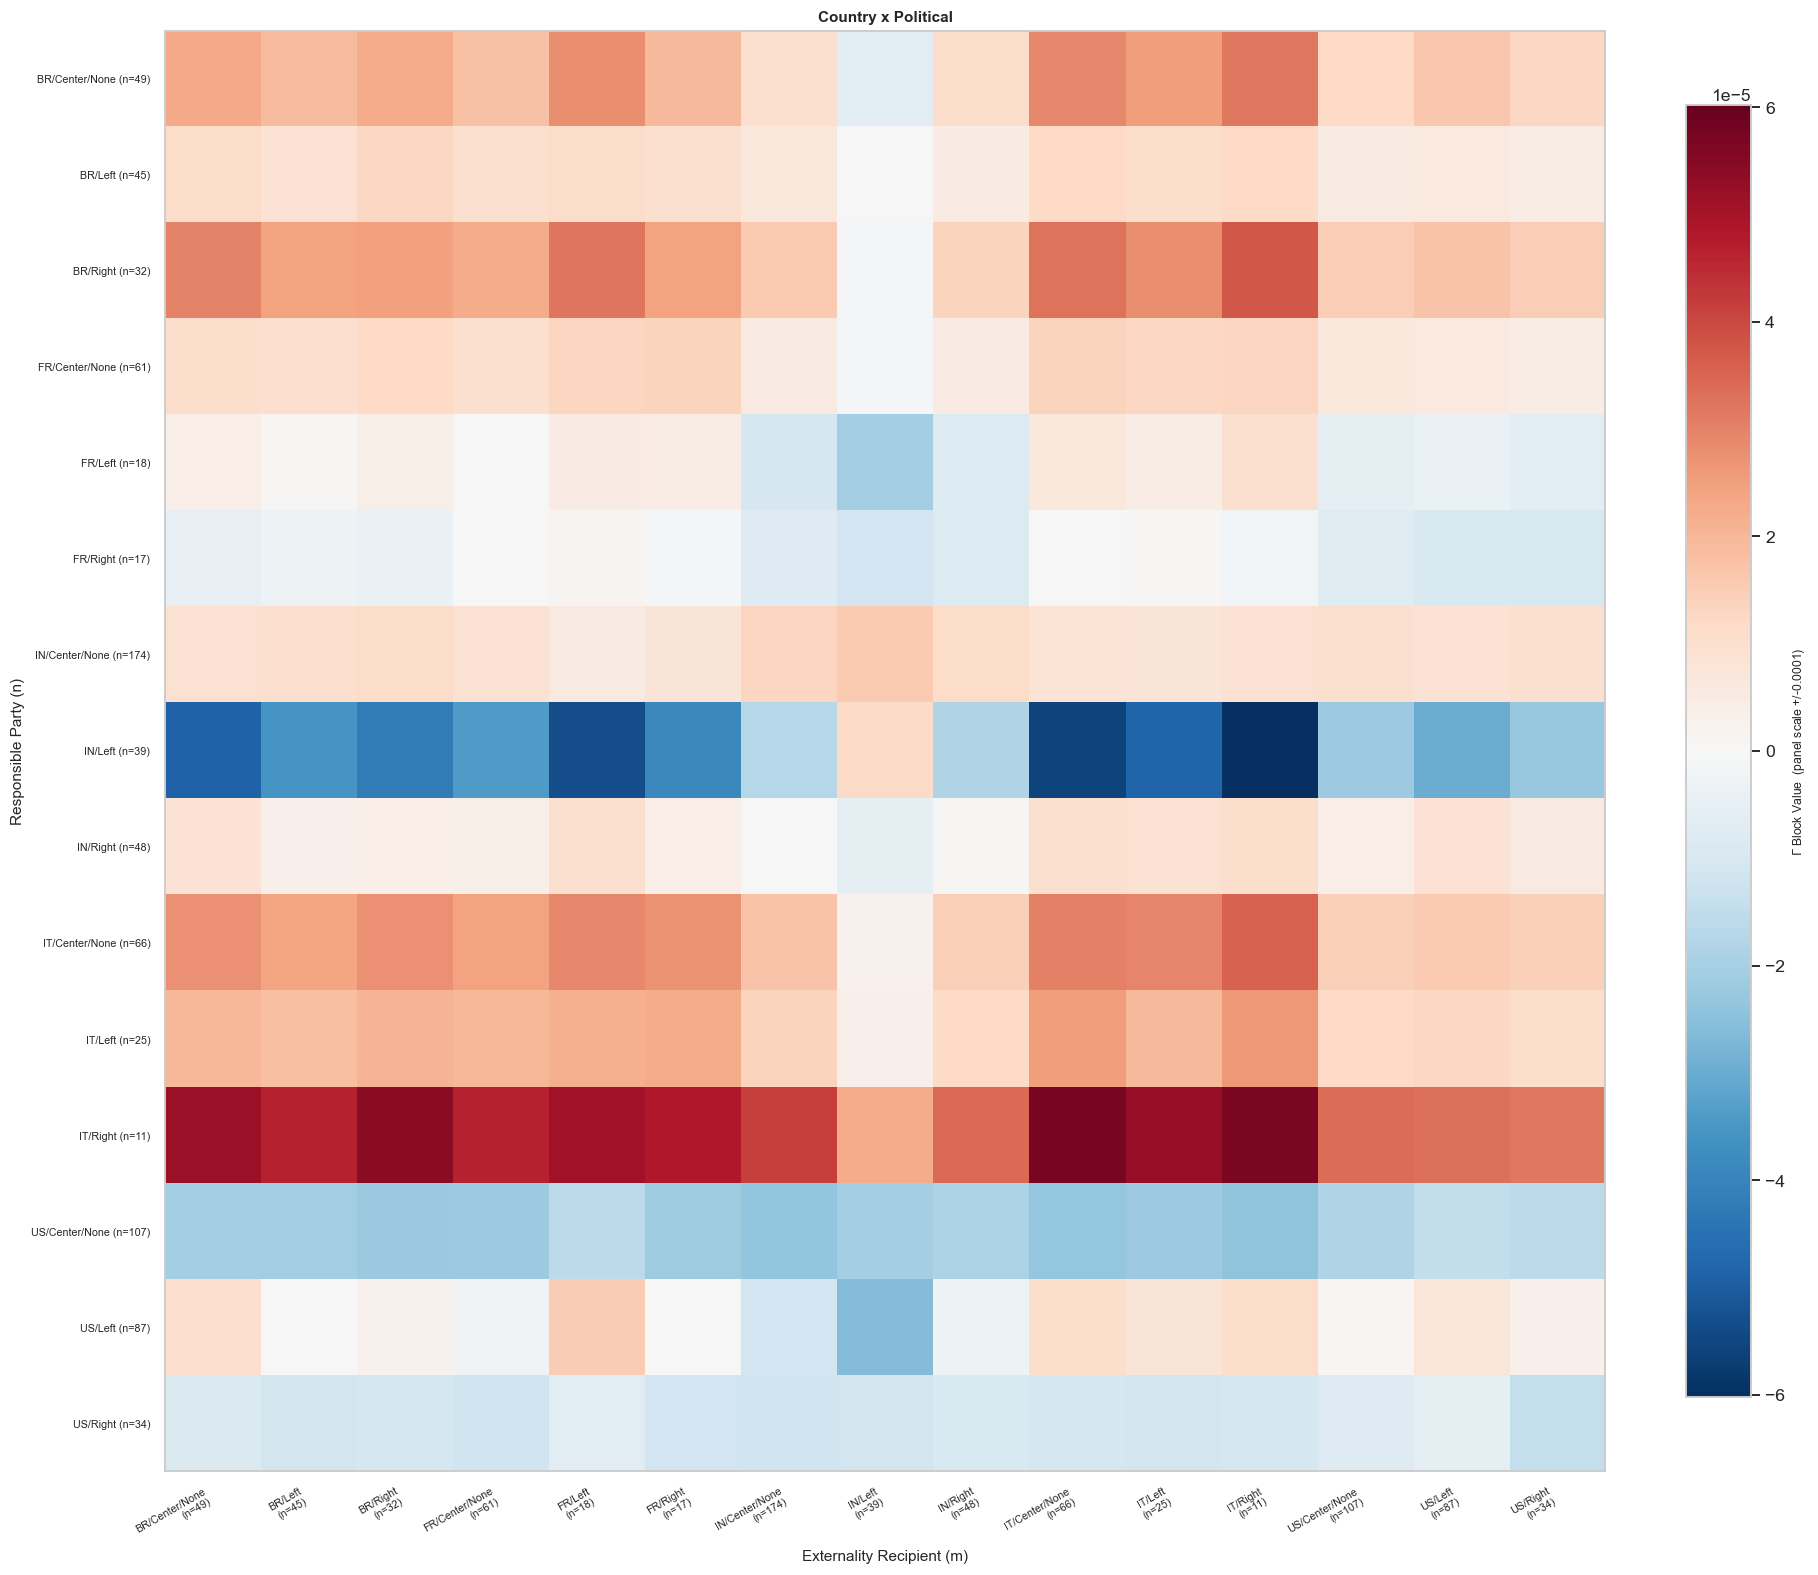

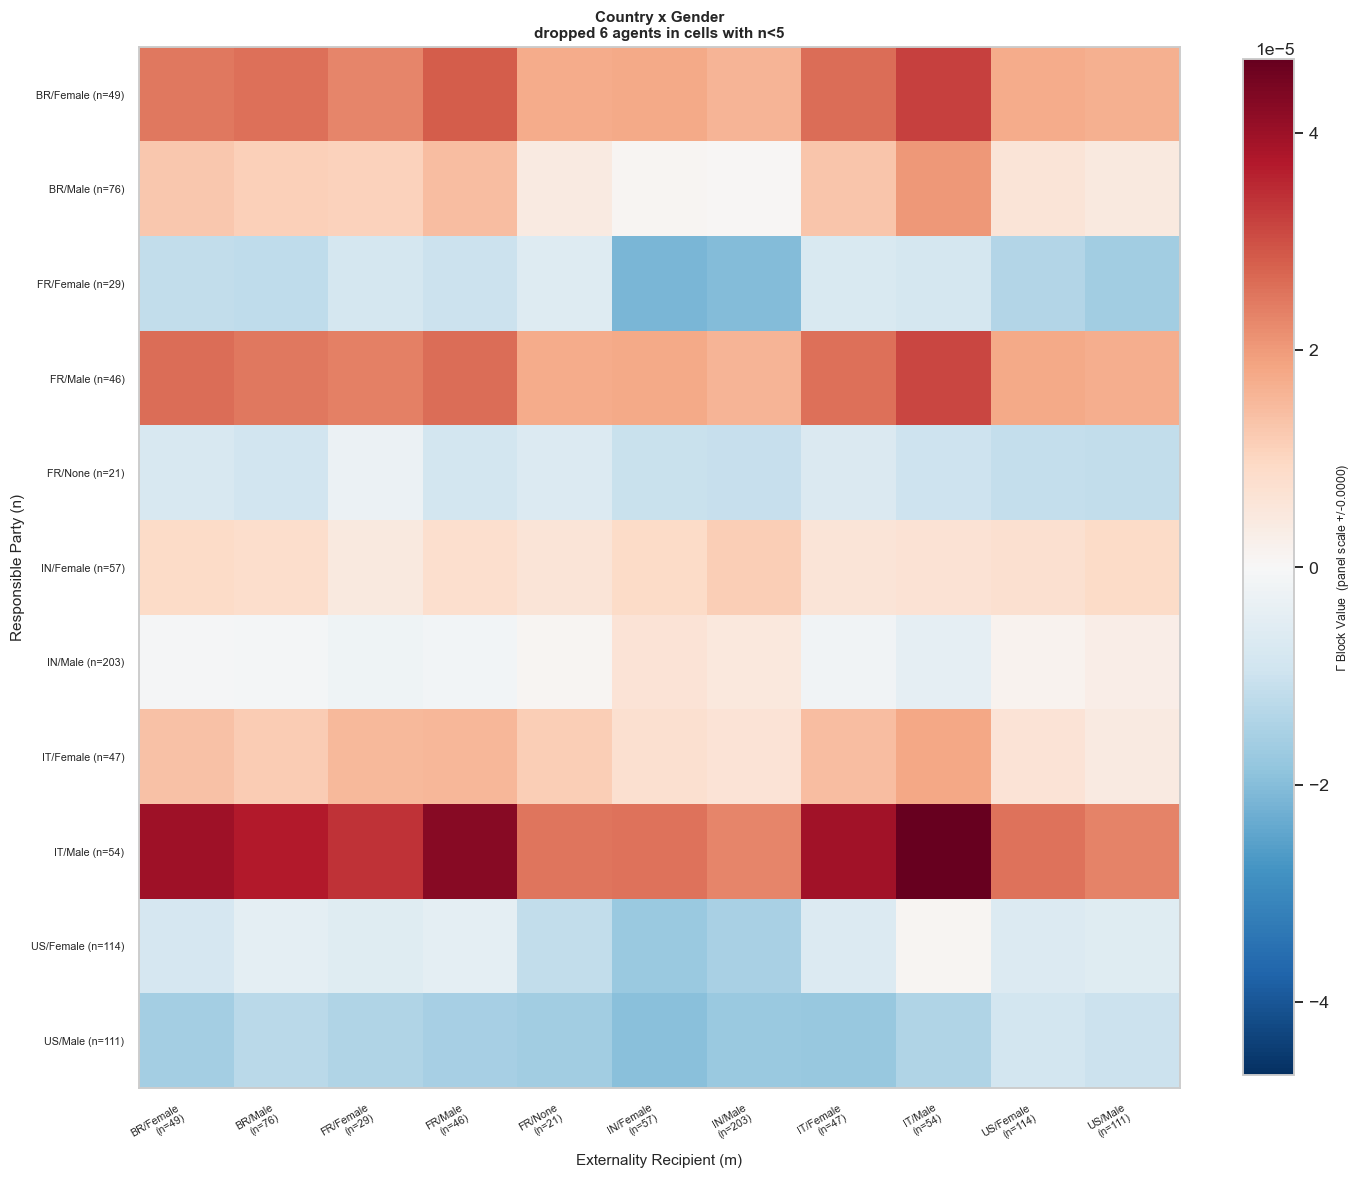

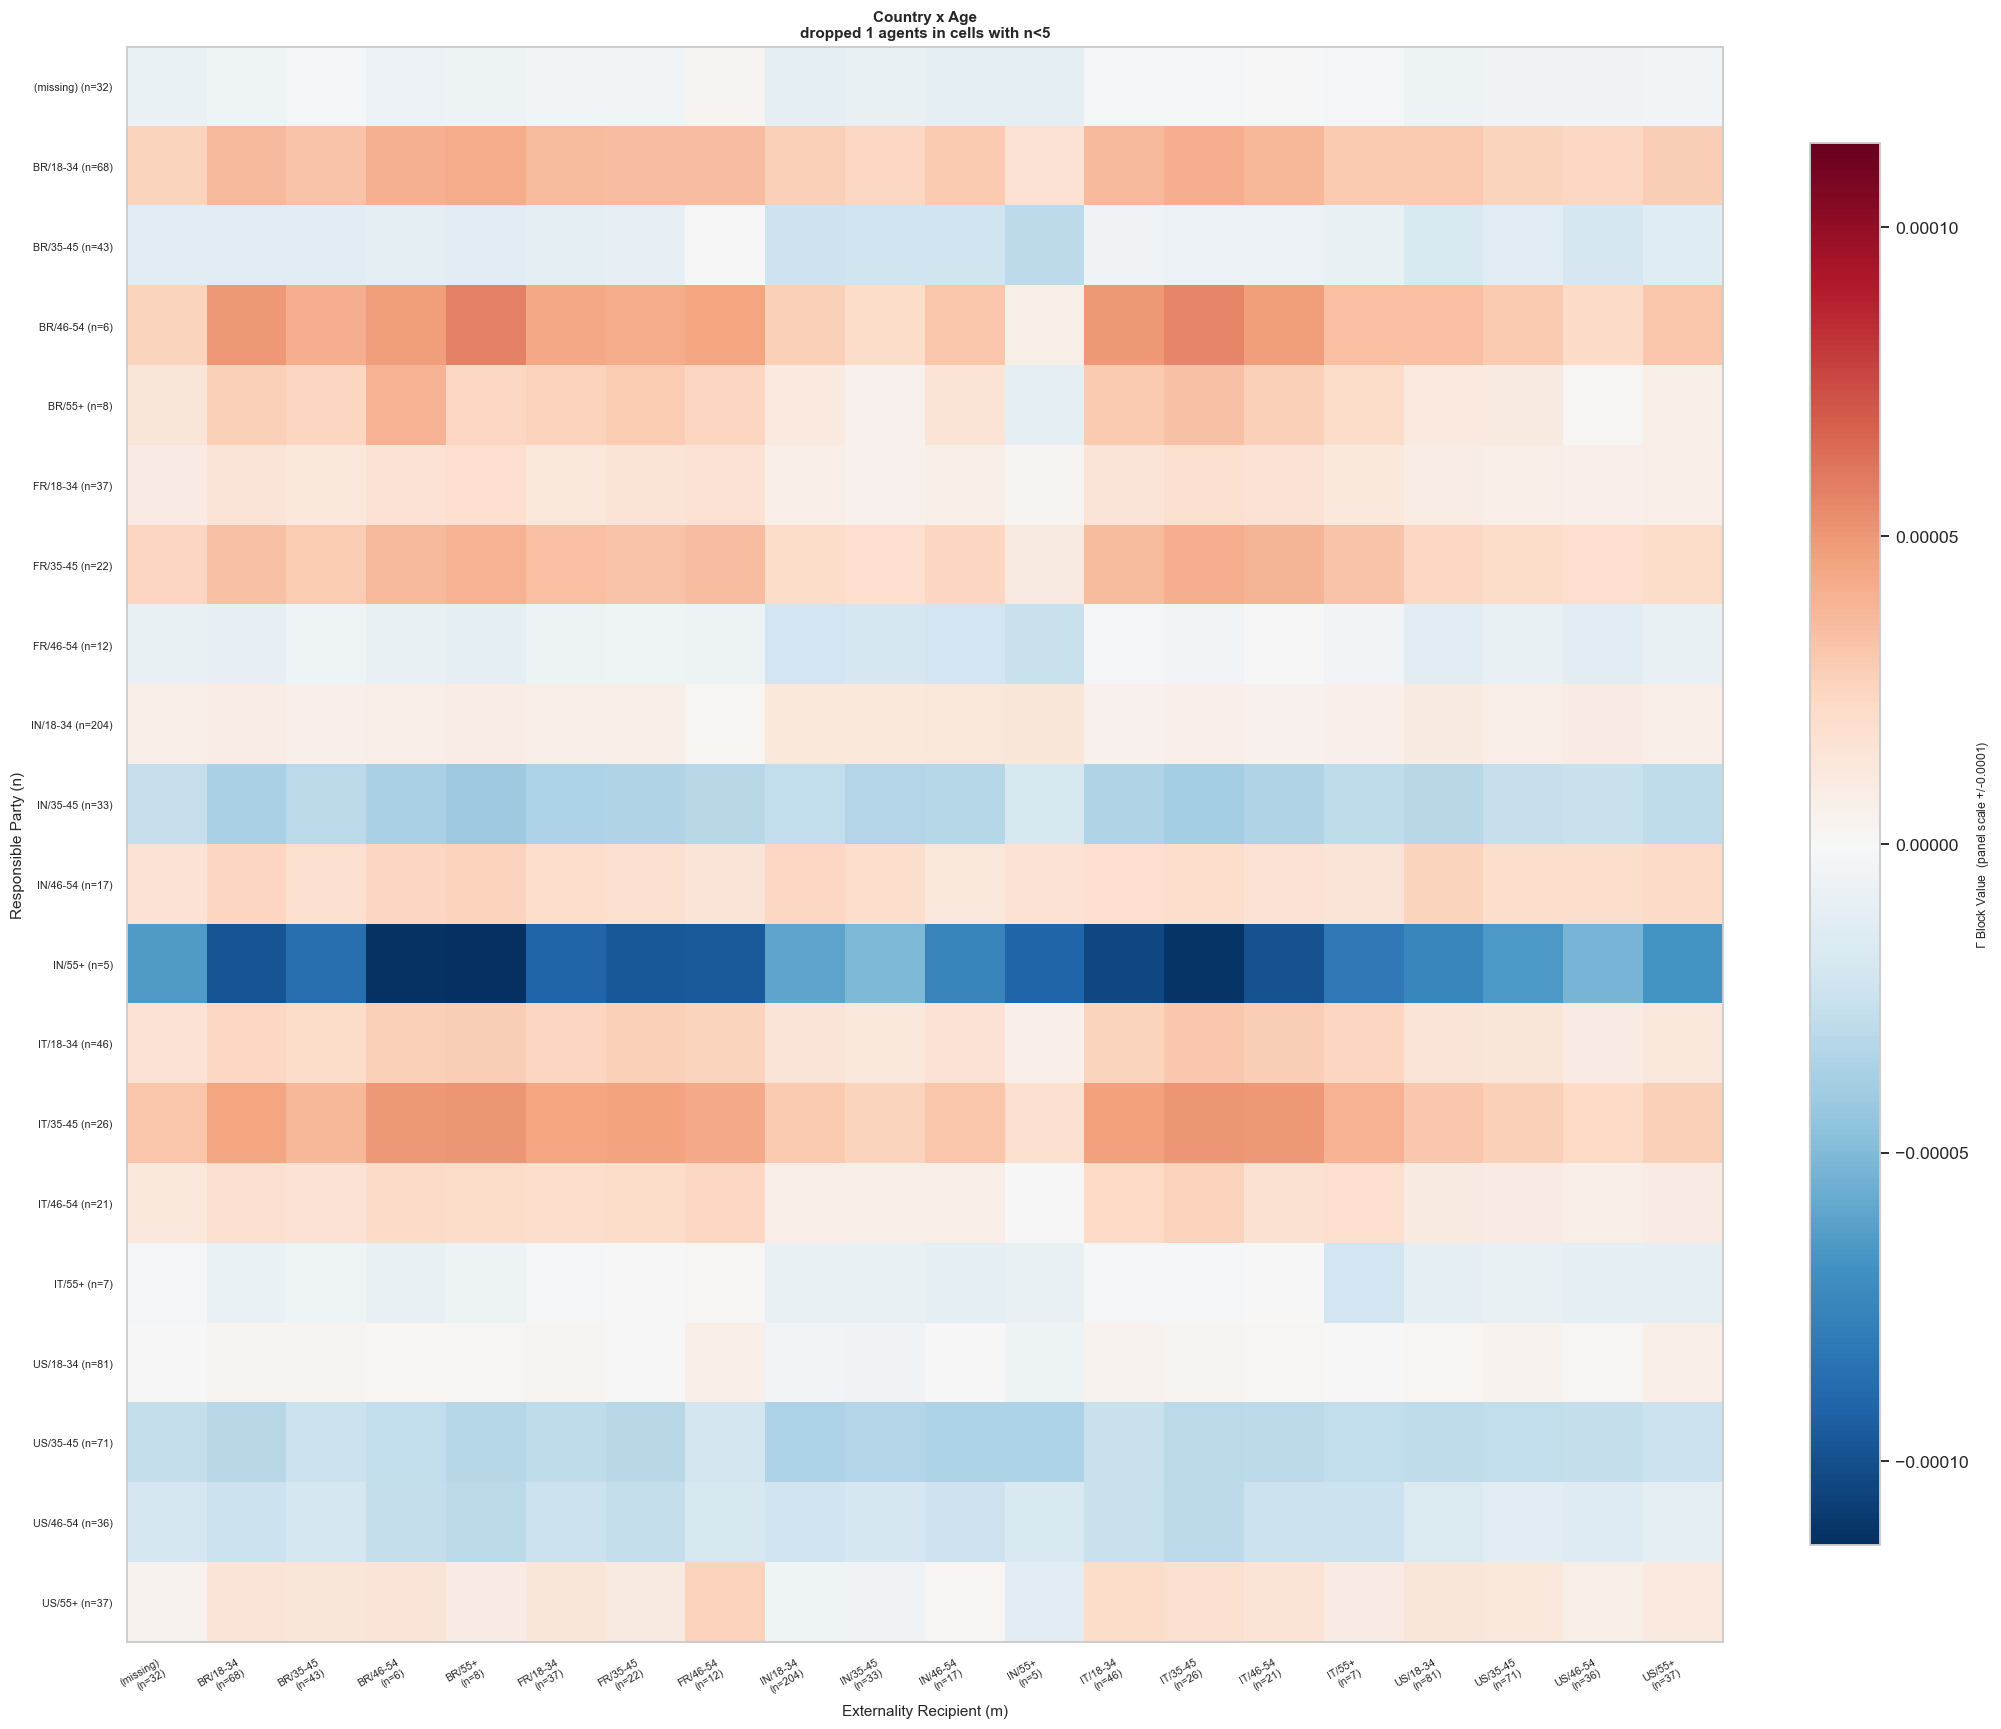

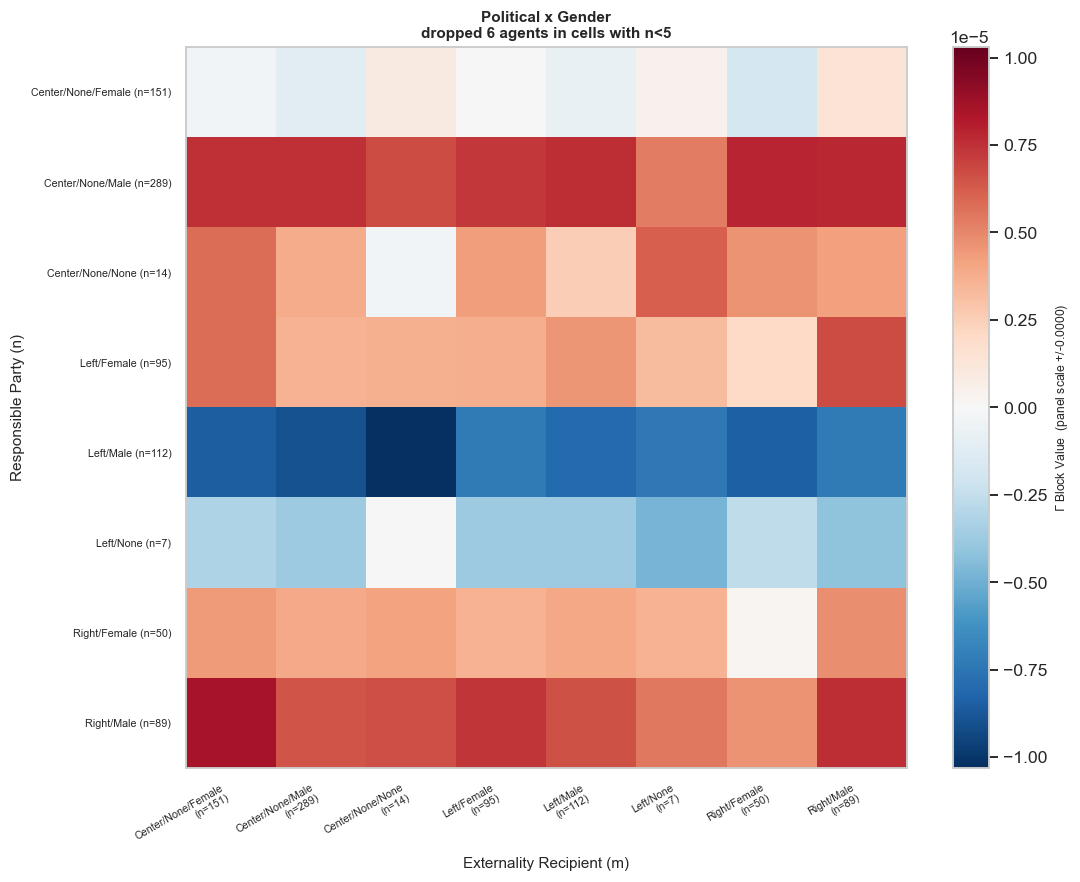

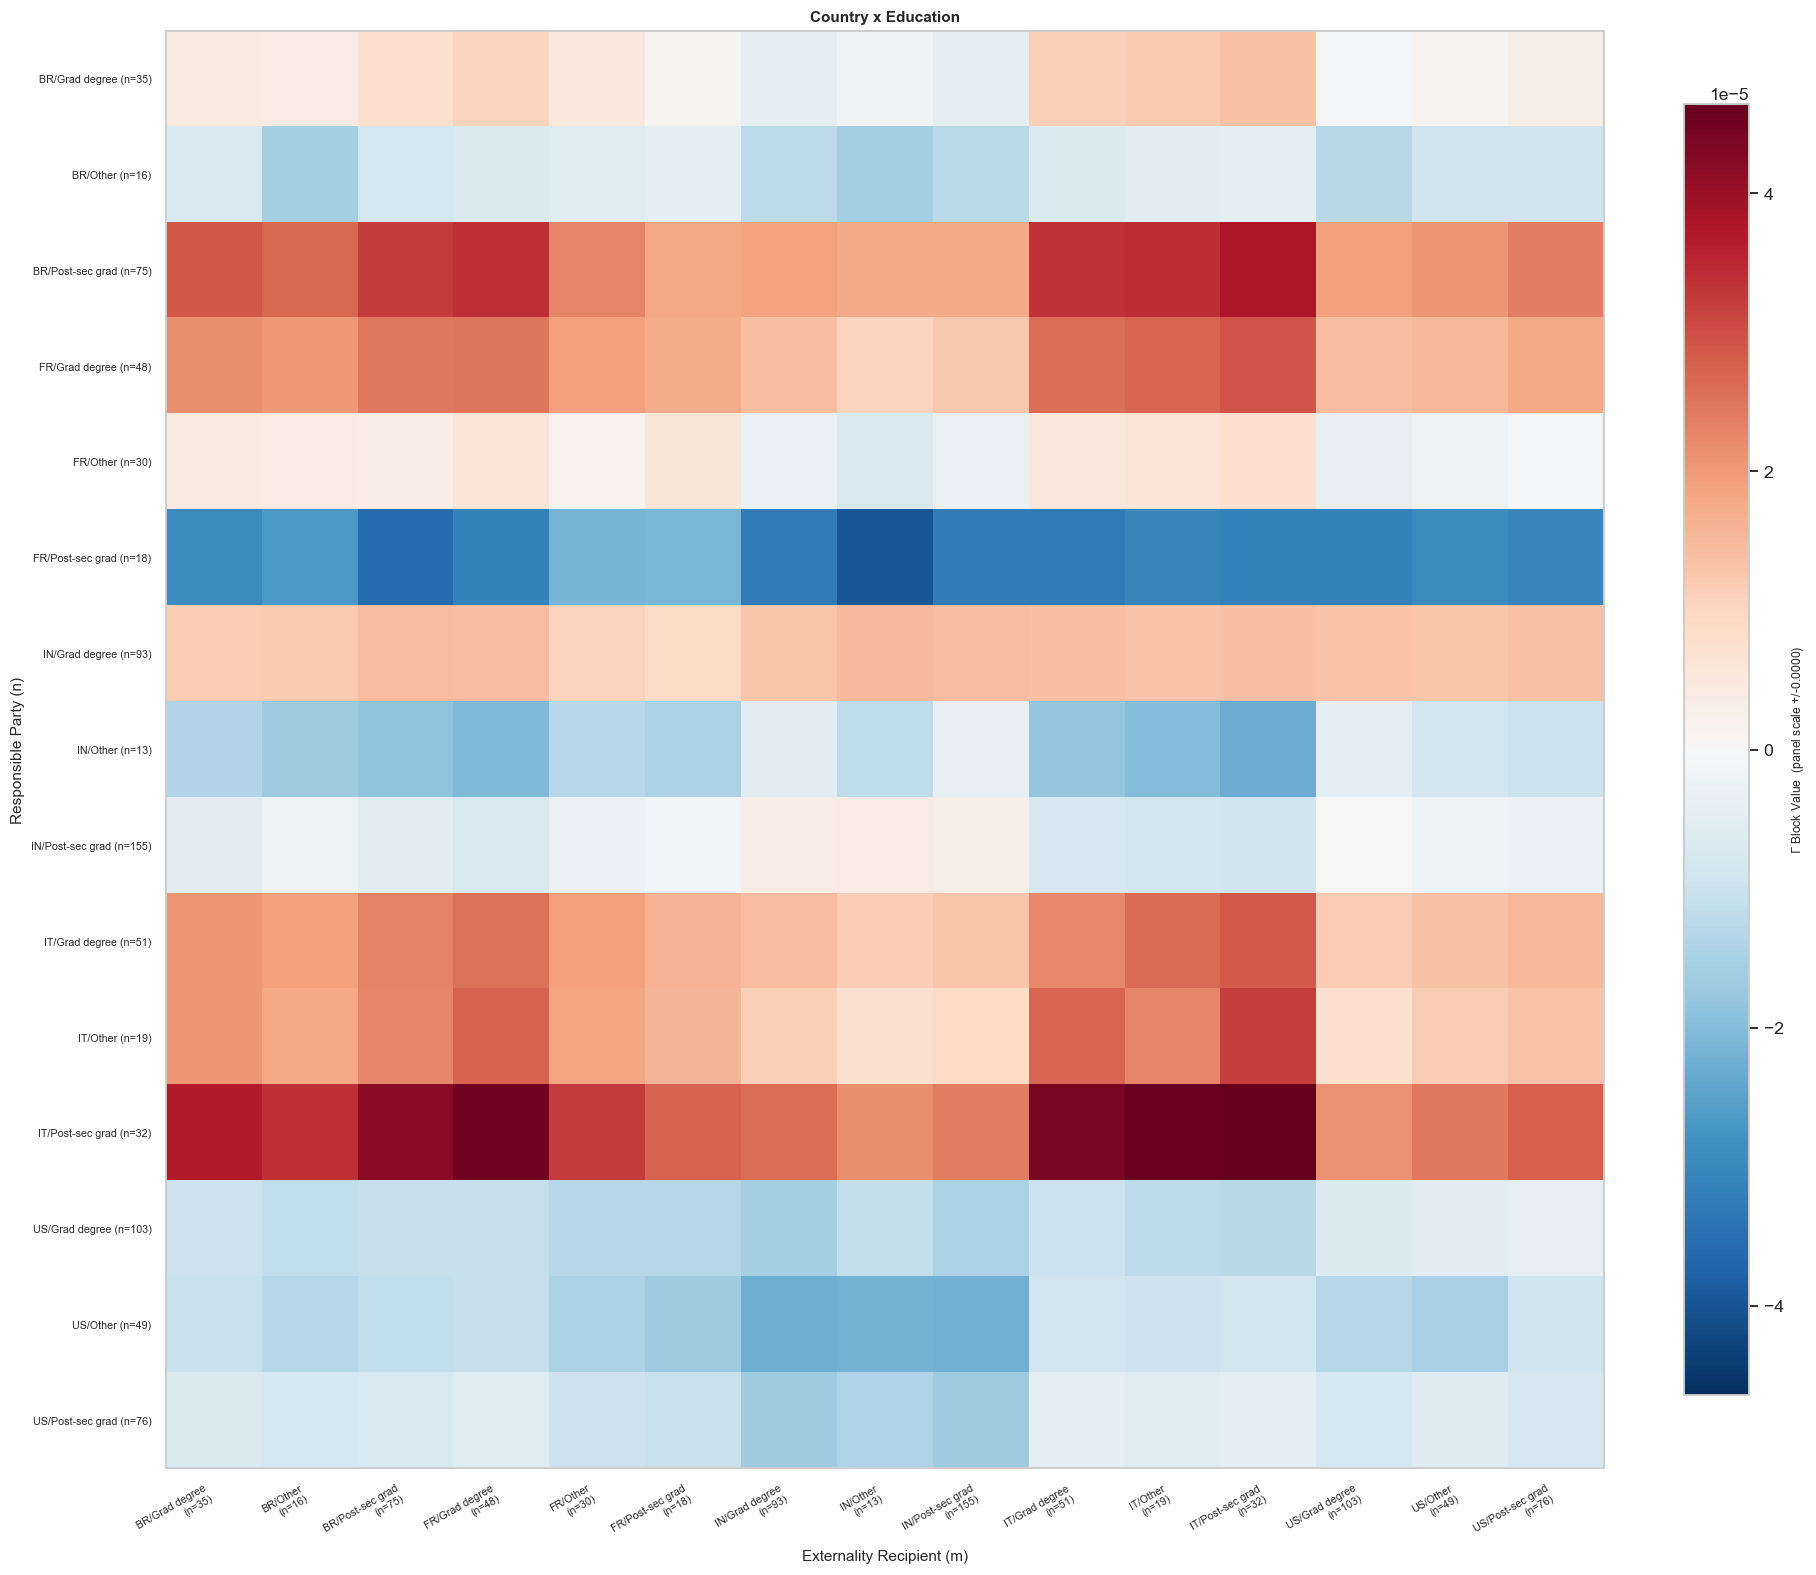


=== ALL axes Γ summary, sorted by |within − across| ===
(positive Δ ⇒ same-group annotators help each other more than cross-group)
               axis  n_groups    within    across      diff  dropped
Country x Political        15  0.000012  0.000005  0.000006        0
            Country         5  0.000011  0.000006  0.000005        0
   Country x Gender        11  0.000010  0.000005  0.000004        6
Country x Education        15  0.000006  0.000003  0.000003        0
          Ethnicity         3  0.000005  0.000003  0.000002        0
      Country x Age        20  0.000003  0.000002  0.000002        1
 Political x Gender         8  0.000001  0.000002 -0.000001        6
                Age         5 -0.000002 -0.000001 -0.000001        0
             Gender         3  0.000001  0.000000  0.000000        4
          Political         3  0.000003  0.000003 -0.000000        0
          Education         3  0.000001  0.000001 -0.000000        0

=== top-10 most-positive group→group ce

In [ ]:
# §7.5 — Cross-demographic externality views (cartesian product of two single axes).
demo_df["country_x_political"] = demo_df["ctry"]        + "/" + demo_df["political_3"]
demo_df["country_x_gender"]    = demo_df["ctry"]        + "/" + demo_df["annotator_gender"]
demo_df["country_x_age"]       = demo_df["ctry"]        + "/" + demo_df["annotator_age"]
demo_df["political_x_gender"]  = demo_df["political_3"] + "/" + demo_df["annotator_gender"]
demo_df["country_x_education"] = demo_df["ctry"]        + "/" + demo_df["education_3"]

CROSS = [
    ("country_x_political", "Country x Political"),
    ("country_x_gender",    "Country x Gender"),
    ("country_x_age",       "Country x Age"),
    ("political_x_gender",  "Political x Gender"),
    ("country_x_education", "Country x Education"),
]

cross_rows = []
for col, label in CROSS:
    g_arr = demo_df[col].to_numpy()
    n_keep = (pd.Series(g_arr).value_counts() >= MIN_CELL_N).sum()
    side   = max(7.0, min(16.0, 1.0 + 0.9 * n_keep))
    fig, ax = plt.subplots(figsize=(side + 2, side))
    row = plot_gamma_heatmap(ax, g_arr, label, fs_lab=7)
    if row: cross_rows.append(row)
    plt.tight_layout(); plt.show()

# Unified summary across all axes — biggest |Δ| is the most-distorting partition.
all_rows = [r for r in (single_rows + cross_rows) if r is not None]
sumdf = pd.DataFrame(all_rows).sort_values("diff", key=abs, ascending=False)
print("\n=== ALL axes Γ summary, sorted by |within − across| ===")
print("(positive Δ ⇒ same-group annotators help each other more than cross-group)")
print(sumdf.round(6).to_string(index=False))

# Top group→group cells across all CROSS axes — the literal "leftist Americans help X" answer.
print("\n=== top-10 most-positive group→group cells across cross-demographic axes ===")
print("(Recipient, Responsible Party, mean Γ — averaged over all (n, m) pairs in that cell)\n")
top_rows = []
for col, label in CROSS:
    g_arr = demo_df[col].to_numpy()
    res = gamma_summary(g_arr)
    if res is None: continue
    G, uniq, counts, _ = res
    for i, gn in enumerate(uniq):
        for j, gm in enumerate(uniq):
            top_rows.append({"axis": label, "Recipient": gn, "Responsible Party": gm,
                             "n_recv": counts[gn], "n_resp": counts[gm],
                             "Γ_block": G[i, j],
                             "diag": (i == j)})
topdf = pd.DataFrame(top_rows)
print("MOST POSITIVE (Responsible Party helps Recipient):")
print(topdf.sort_values("Γ_block", ascending=False).head(10).round(6).to_string(index=False))
print("\nMOST NEGATIVE (Responsible Party hurts Recipient):")
print(topdf.sort_values("Γ_block", ascending=True).head(10).round(6).to_string(index=False))

### §7.6 Group-level LOO heatmaps — leave-the-whole-group-out

The §7.4 and §7.5 heatmaps **average** the per-pair LOO externality `Γ_{n,m}` within each group block — that's a per-pair quantity that captures *internal preference (in)homogeneity*. Same-group cell ≈ 0 doesn't mean the group has no impact on itself; it means a typical pair of within-group members don't affect each other much marginally.

This section answers the complementary question: **"what if the entire group hadn't been in the dataset?"** — the leave-group-out impact, all interaction effects intact.

For each demographic axis and each group G:

1. Refit pooled BTL with **all** of G's rows removed → `θ̂_{-G}`, then `ψ_{-G} = ψ(θ̂_{-G})`.
2. Build the receiver × giver heatmap with entry `[i, j] = θ̄_{group i}ᵀ (ψ_full − ψ_{-group j})` — i.e., *the average group-i member's welfare effect from group j being included as a whole*.

The diagonal entry `[G, G]` is the average G-member's stake in their own group's inclusion. Off-diagonal `[i, j]` is the asymmetric cross-group externality. A small additional cost (~`n_groups` refits per axis instead of `N_AGENTS`), so this runs in well under a minute even with the cross-demographic axes.

running group-level LOO refits for single demographic axes...


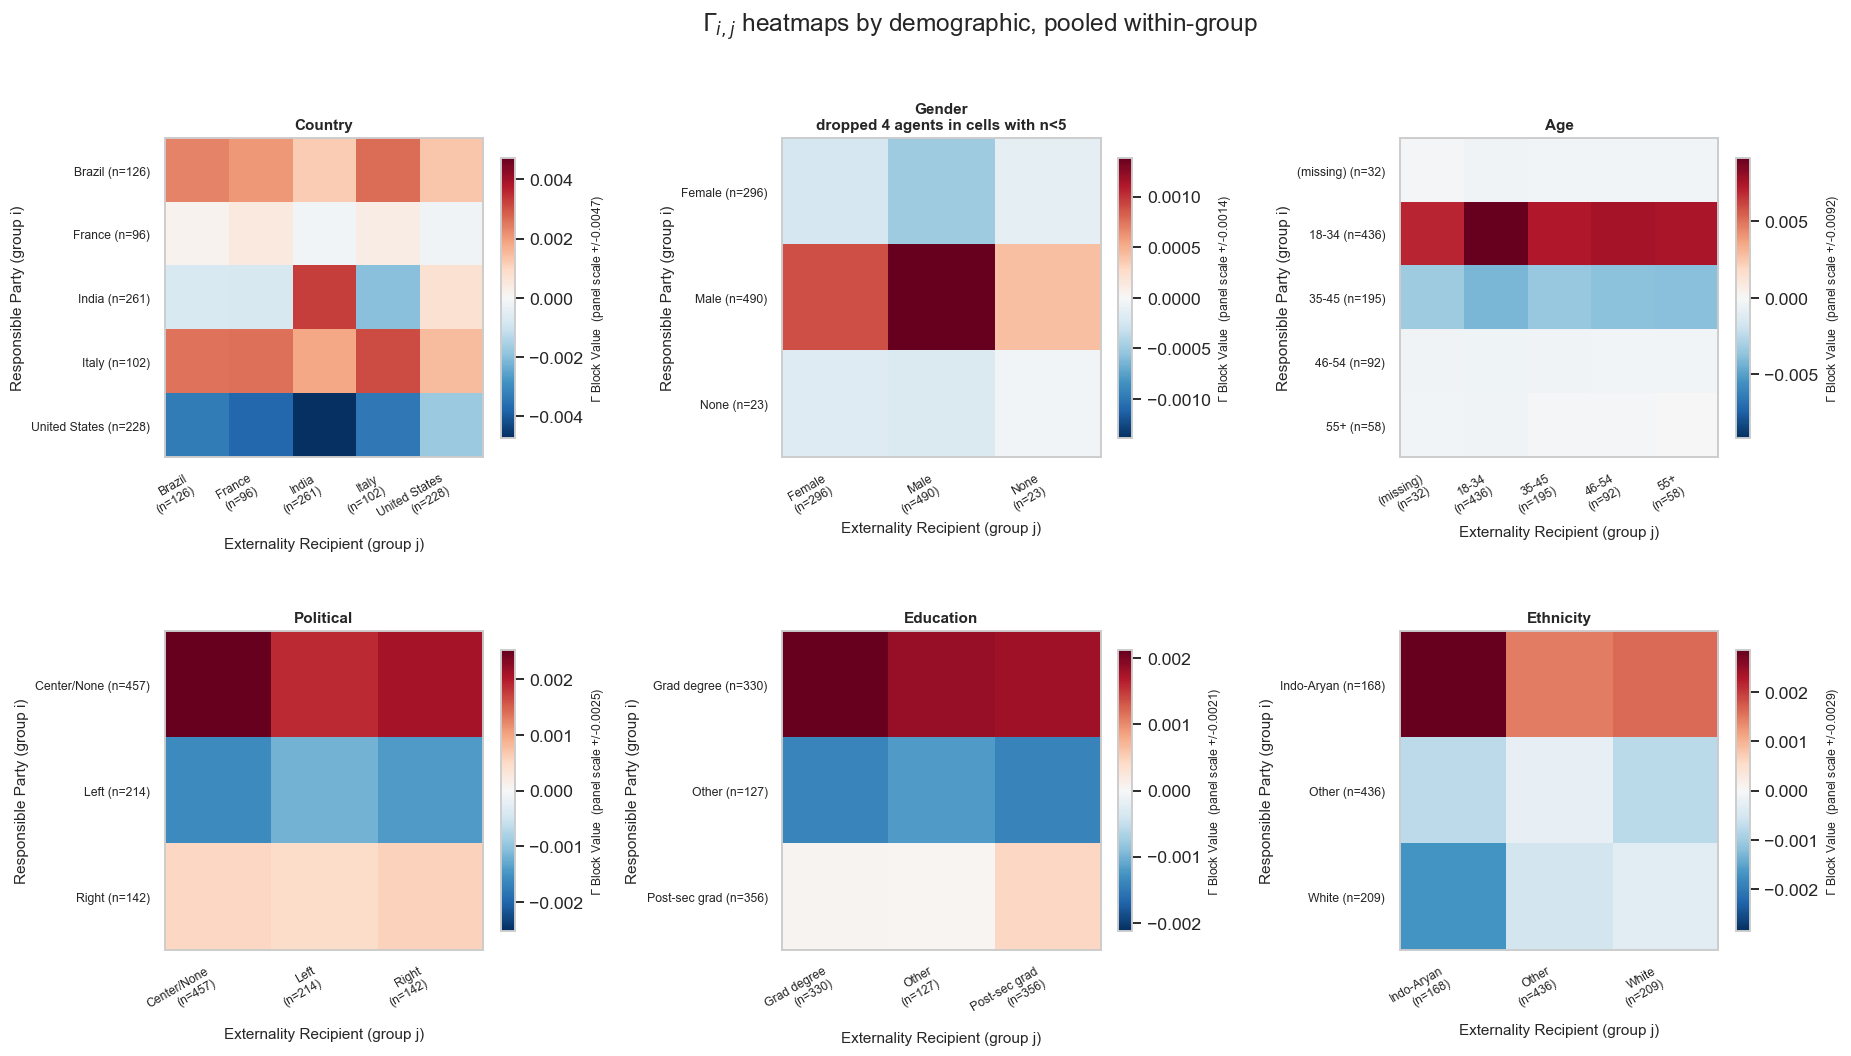

  single demographics done in 5.6s


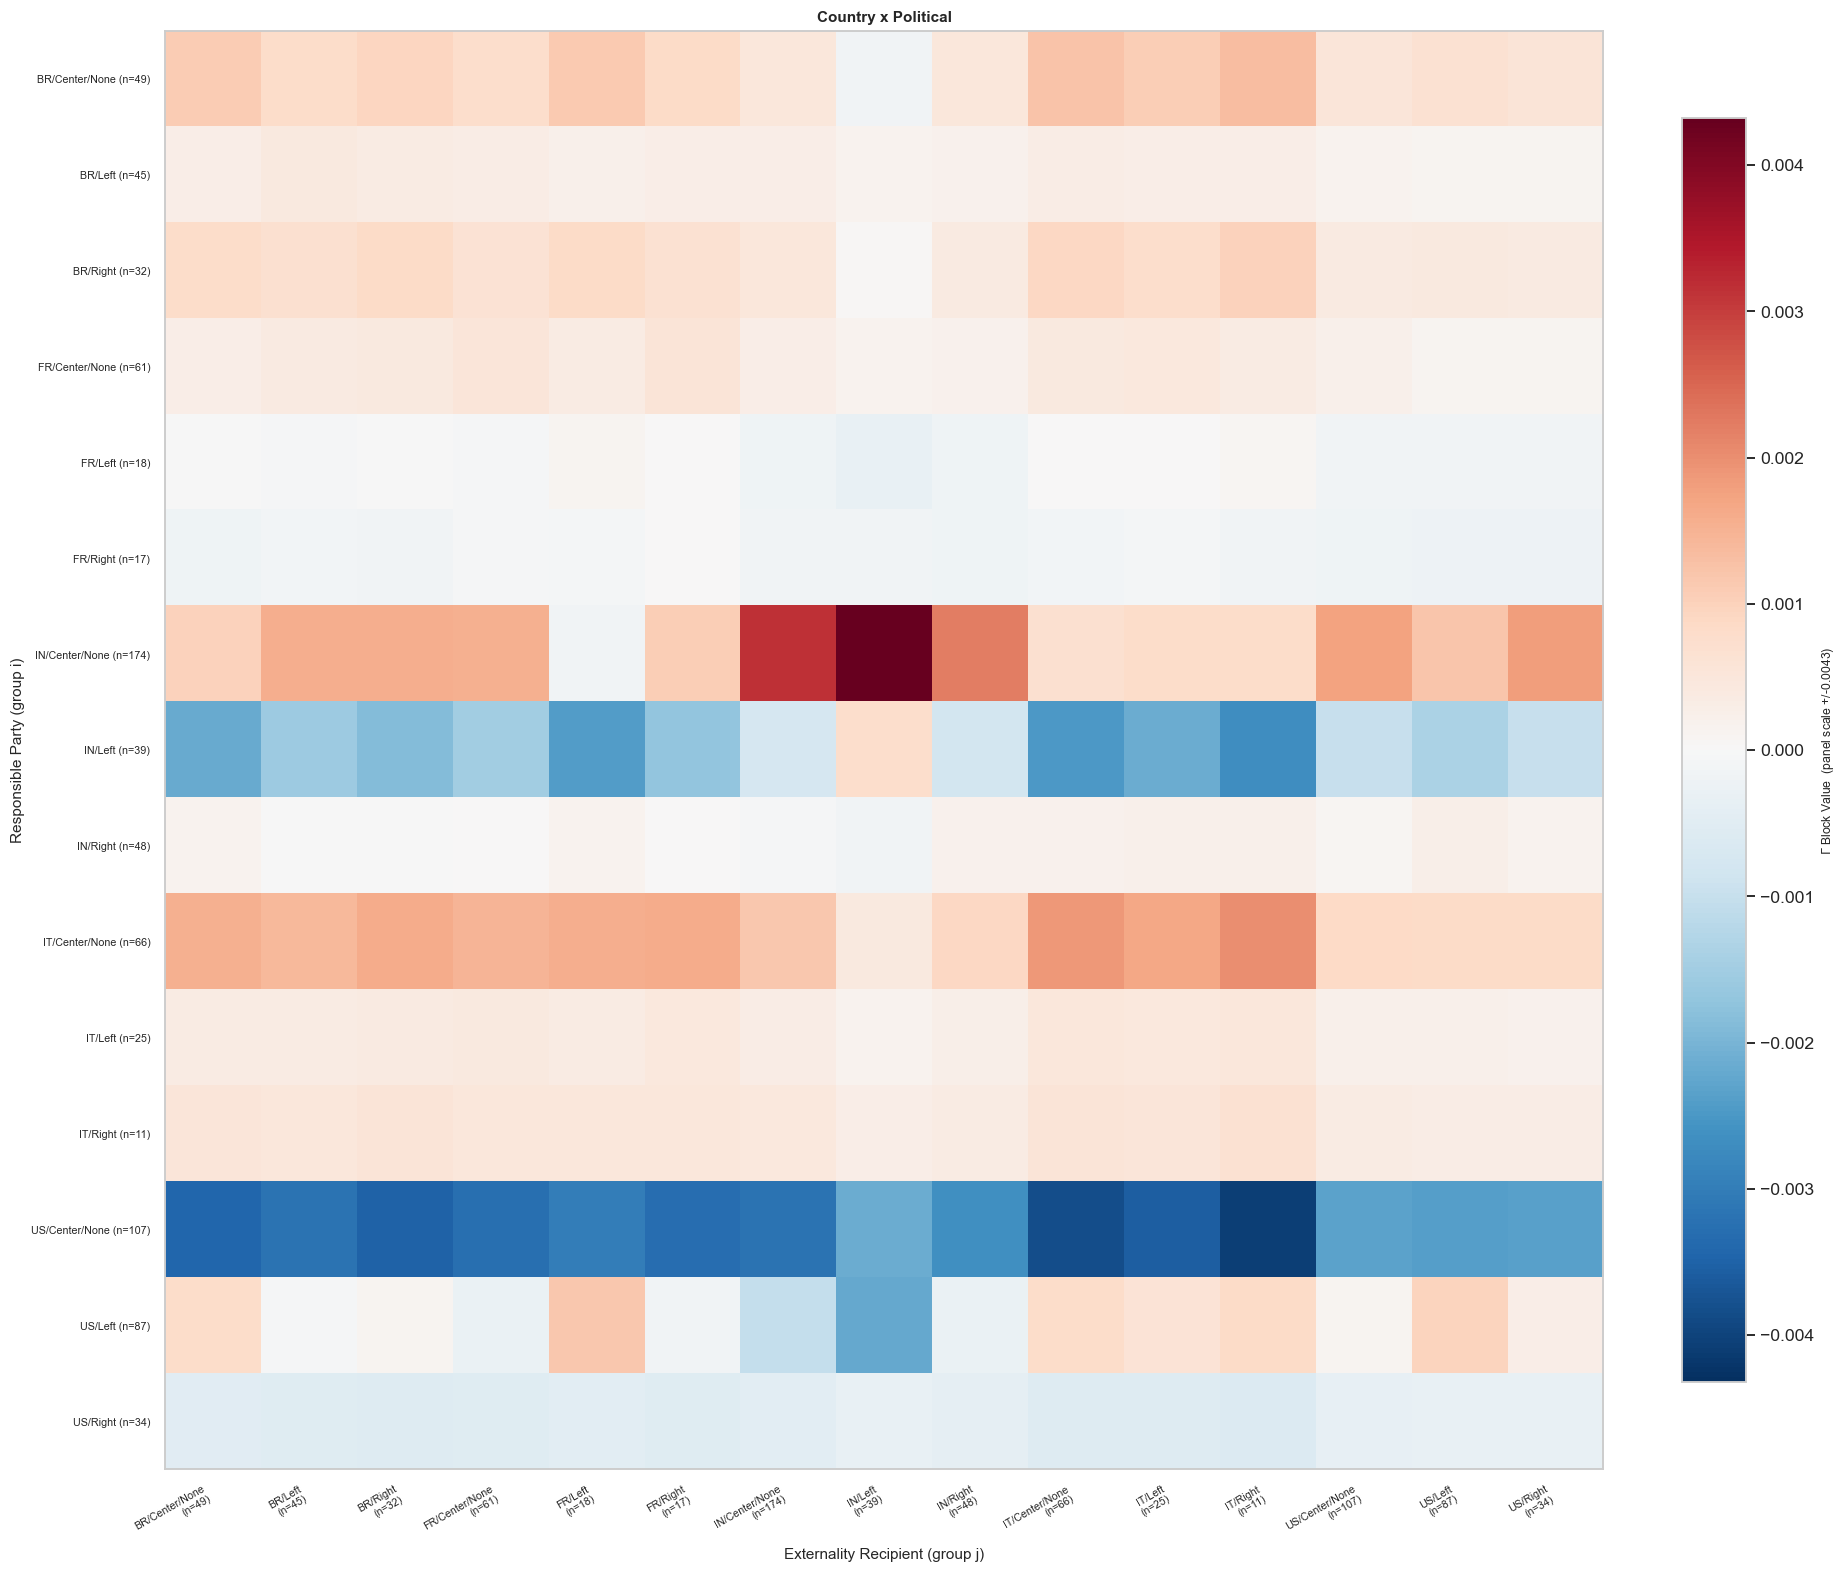

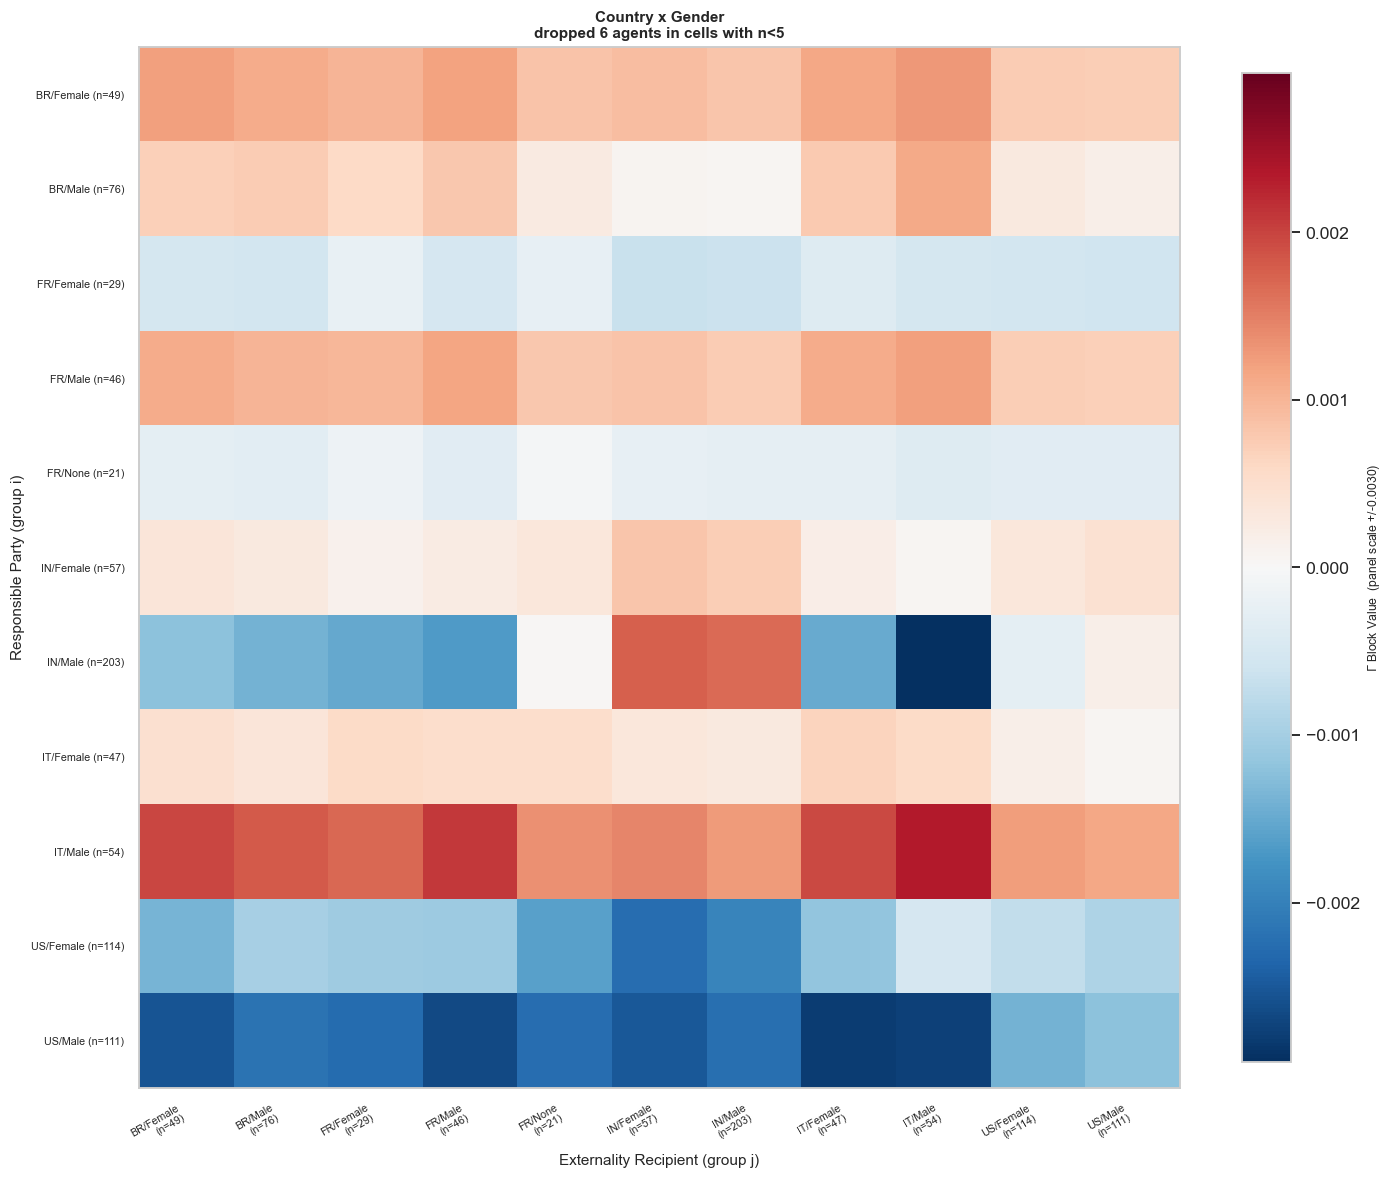

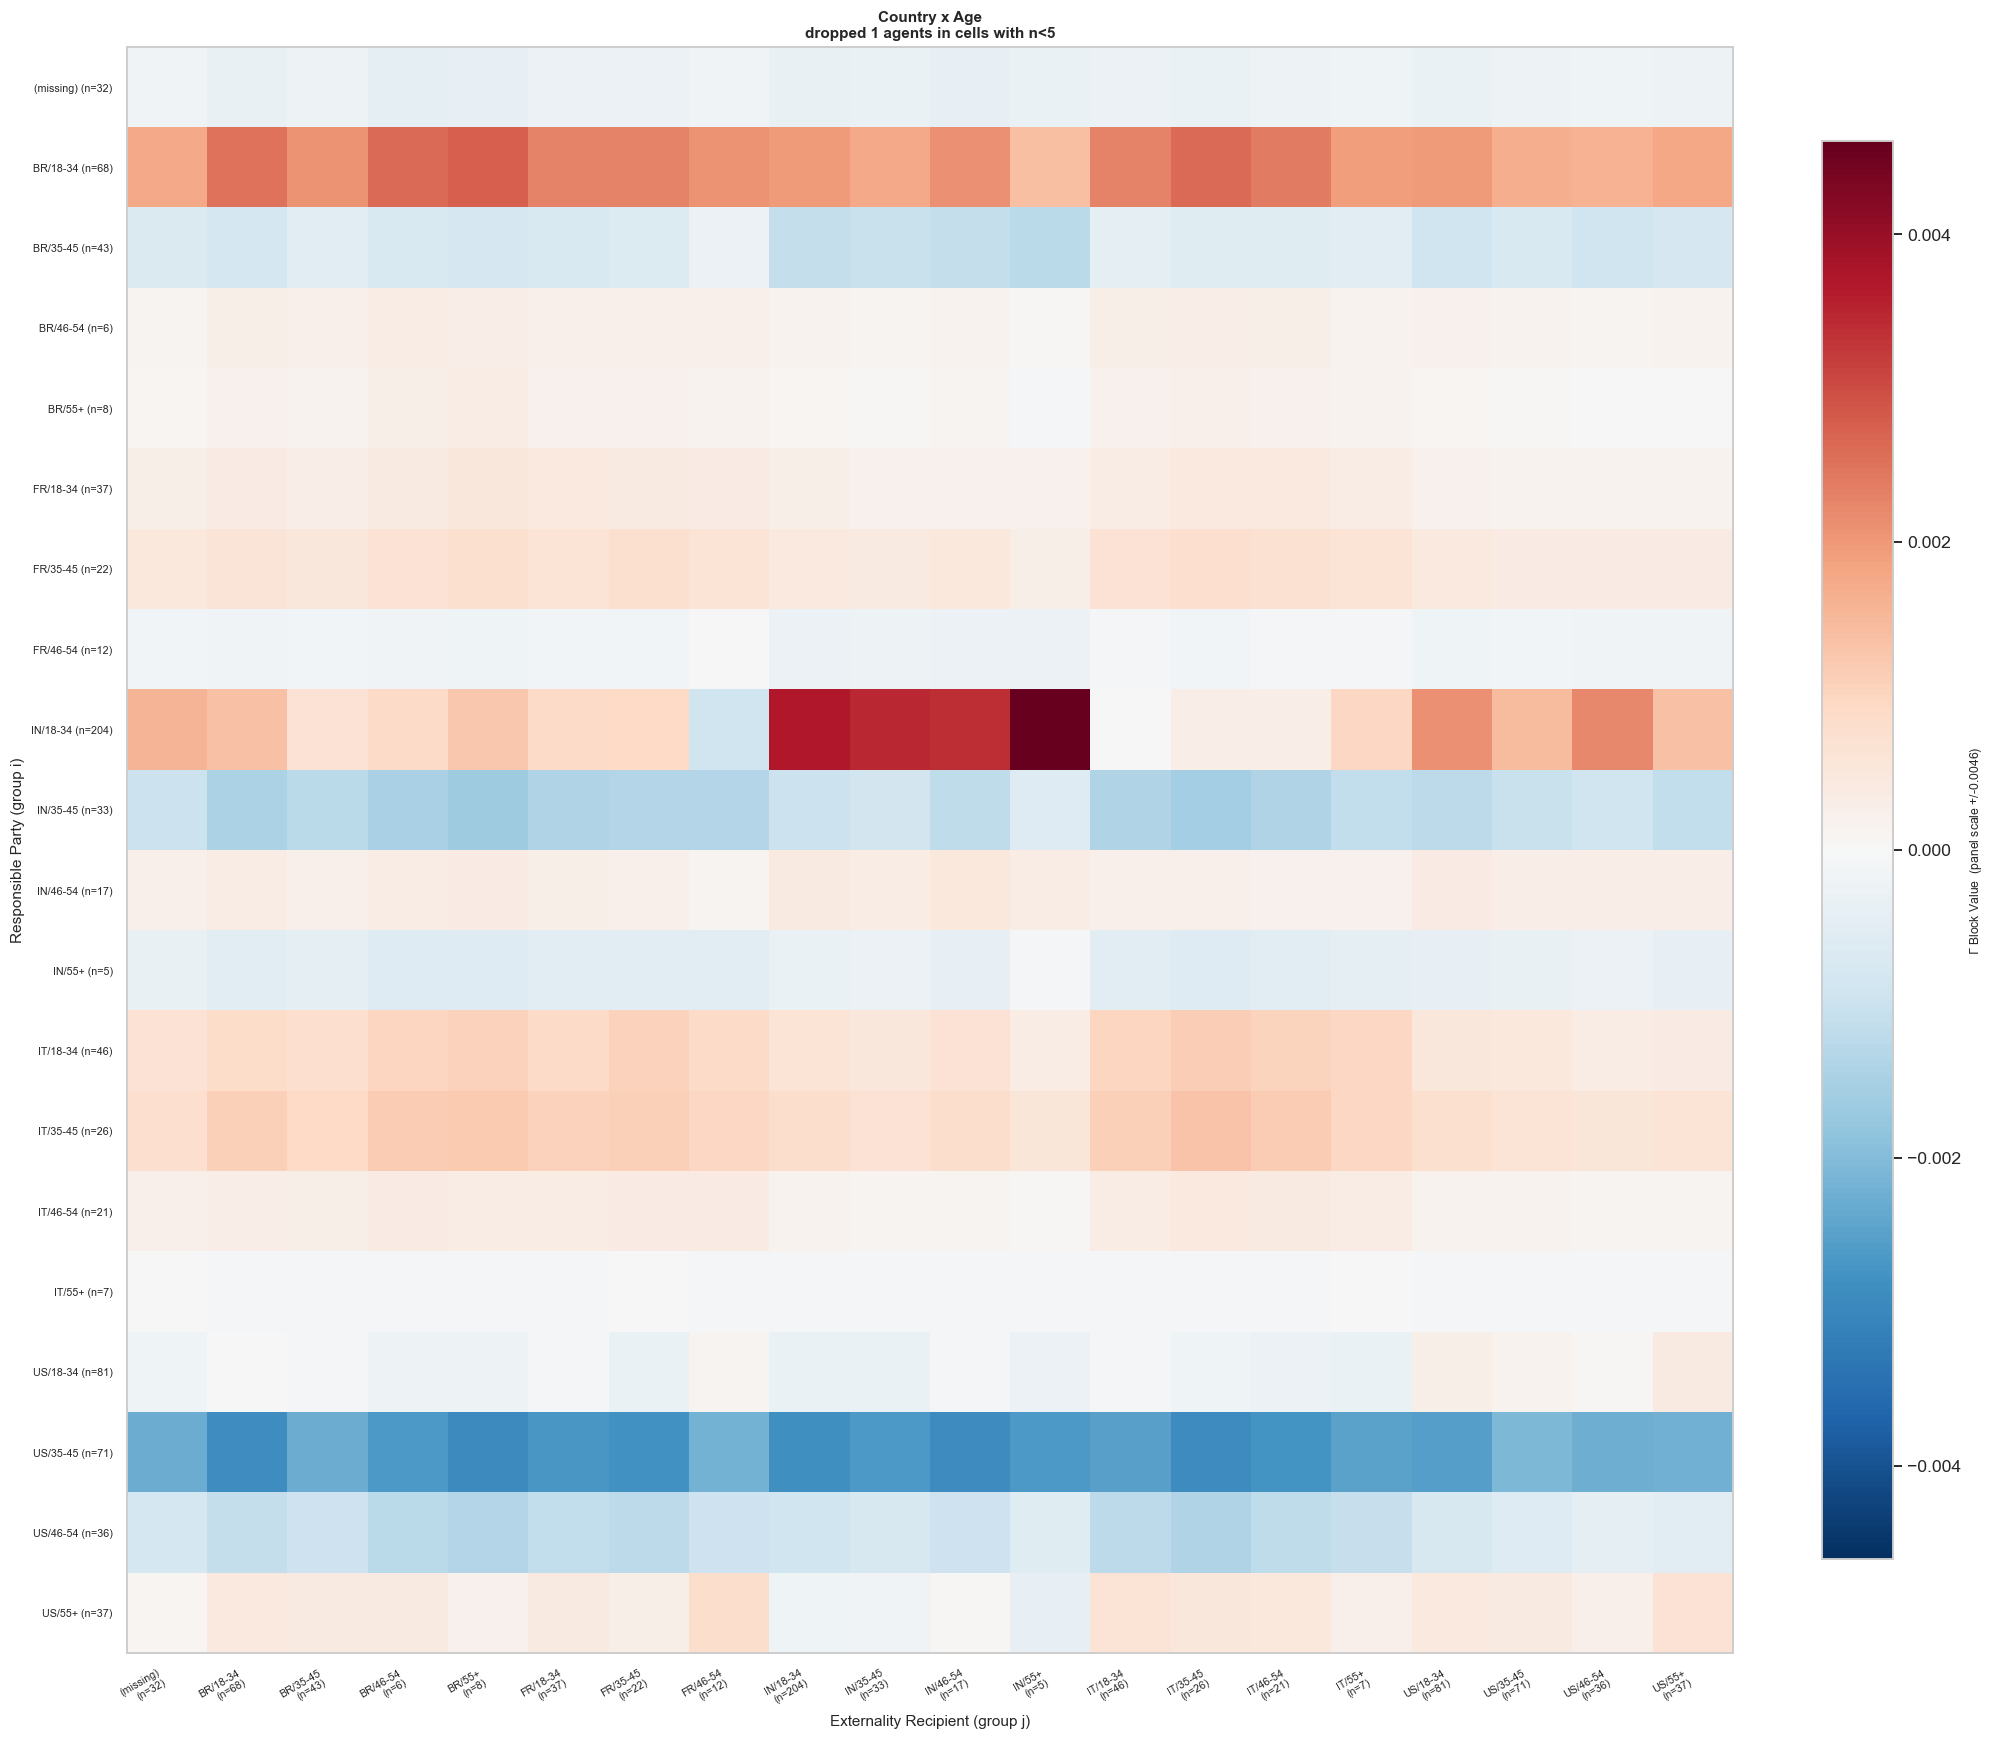

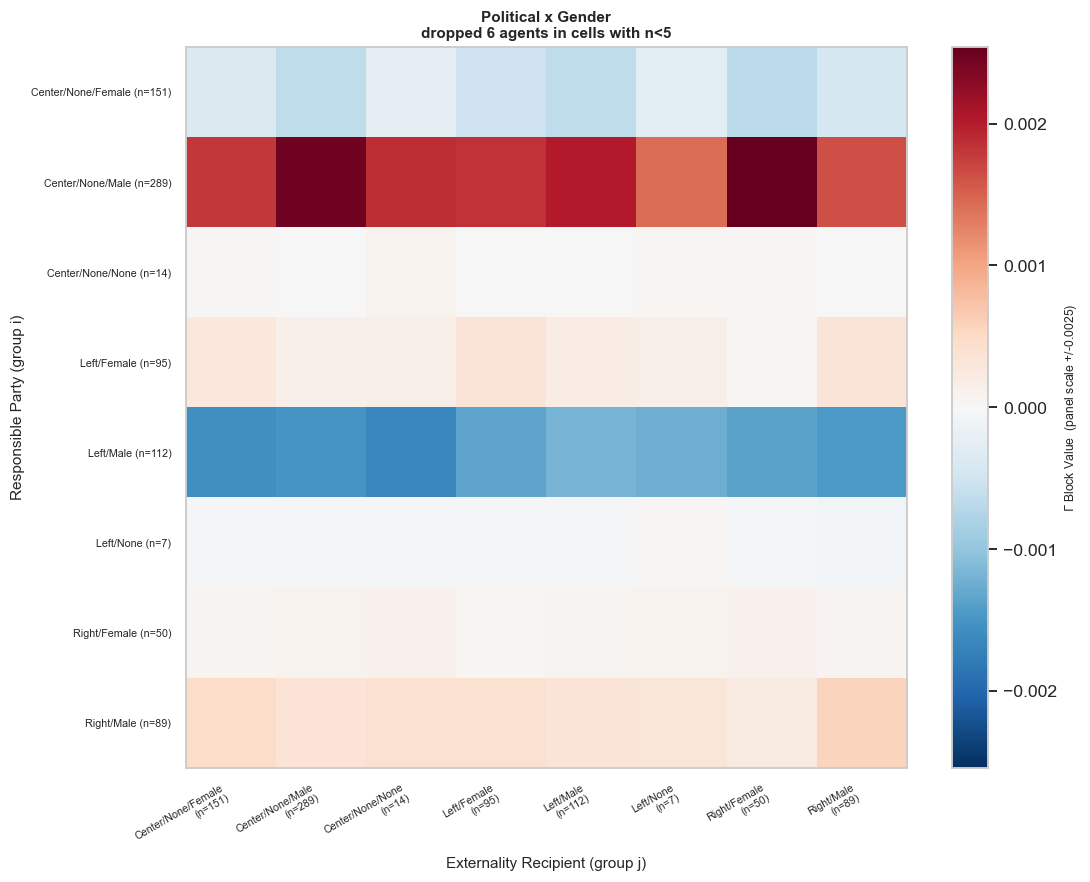

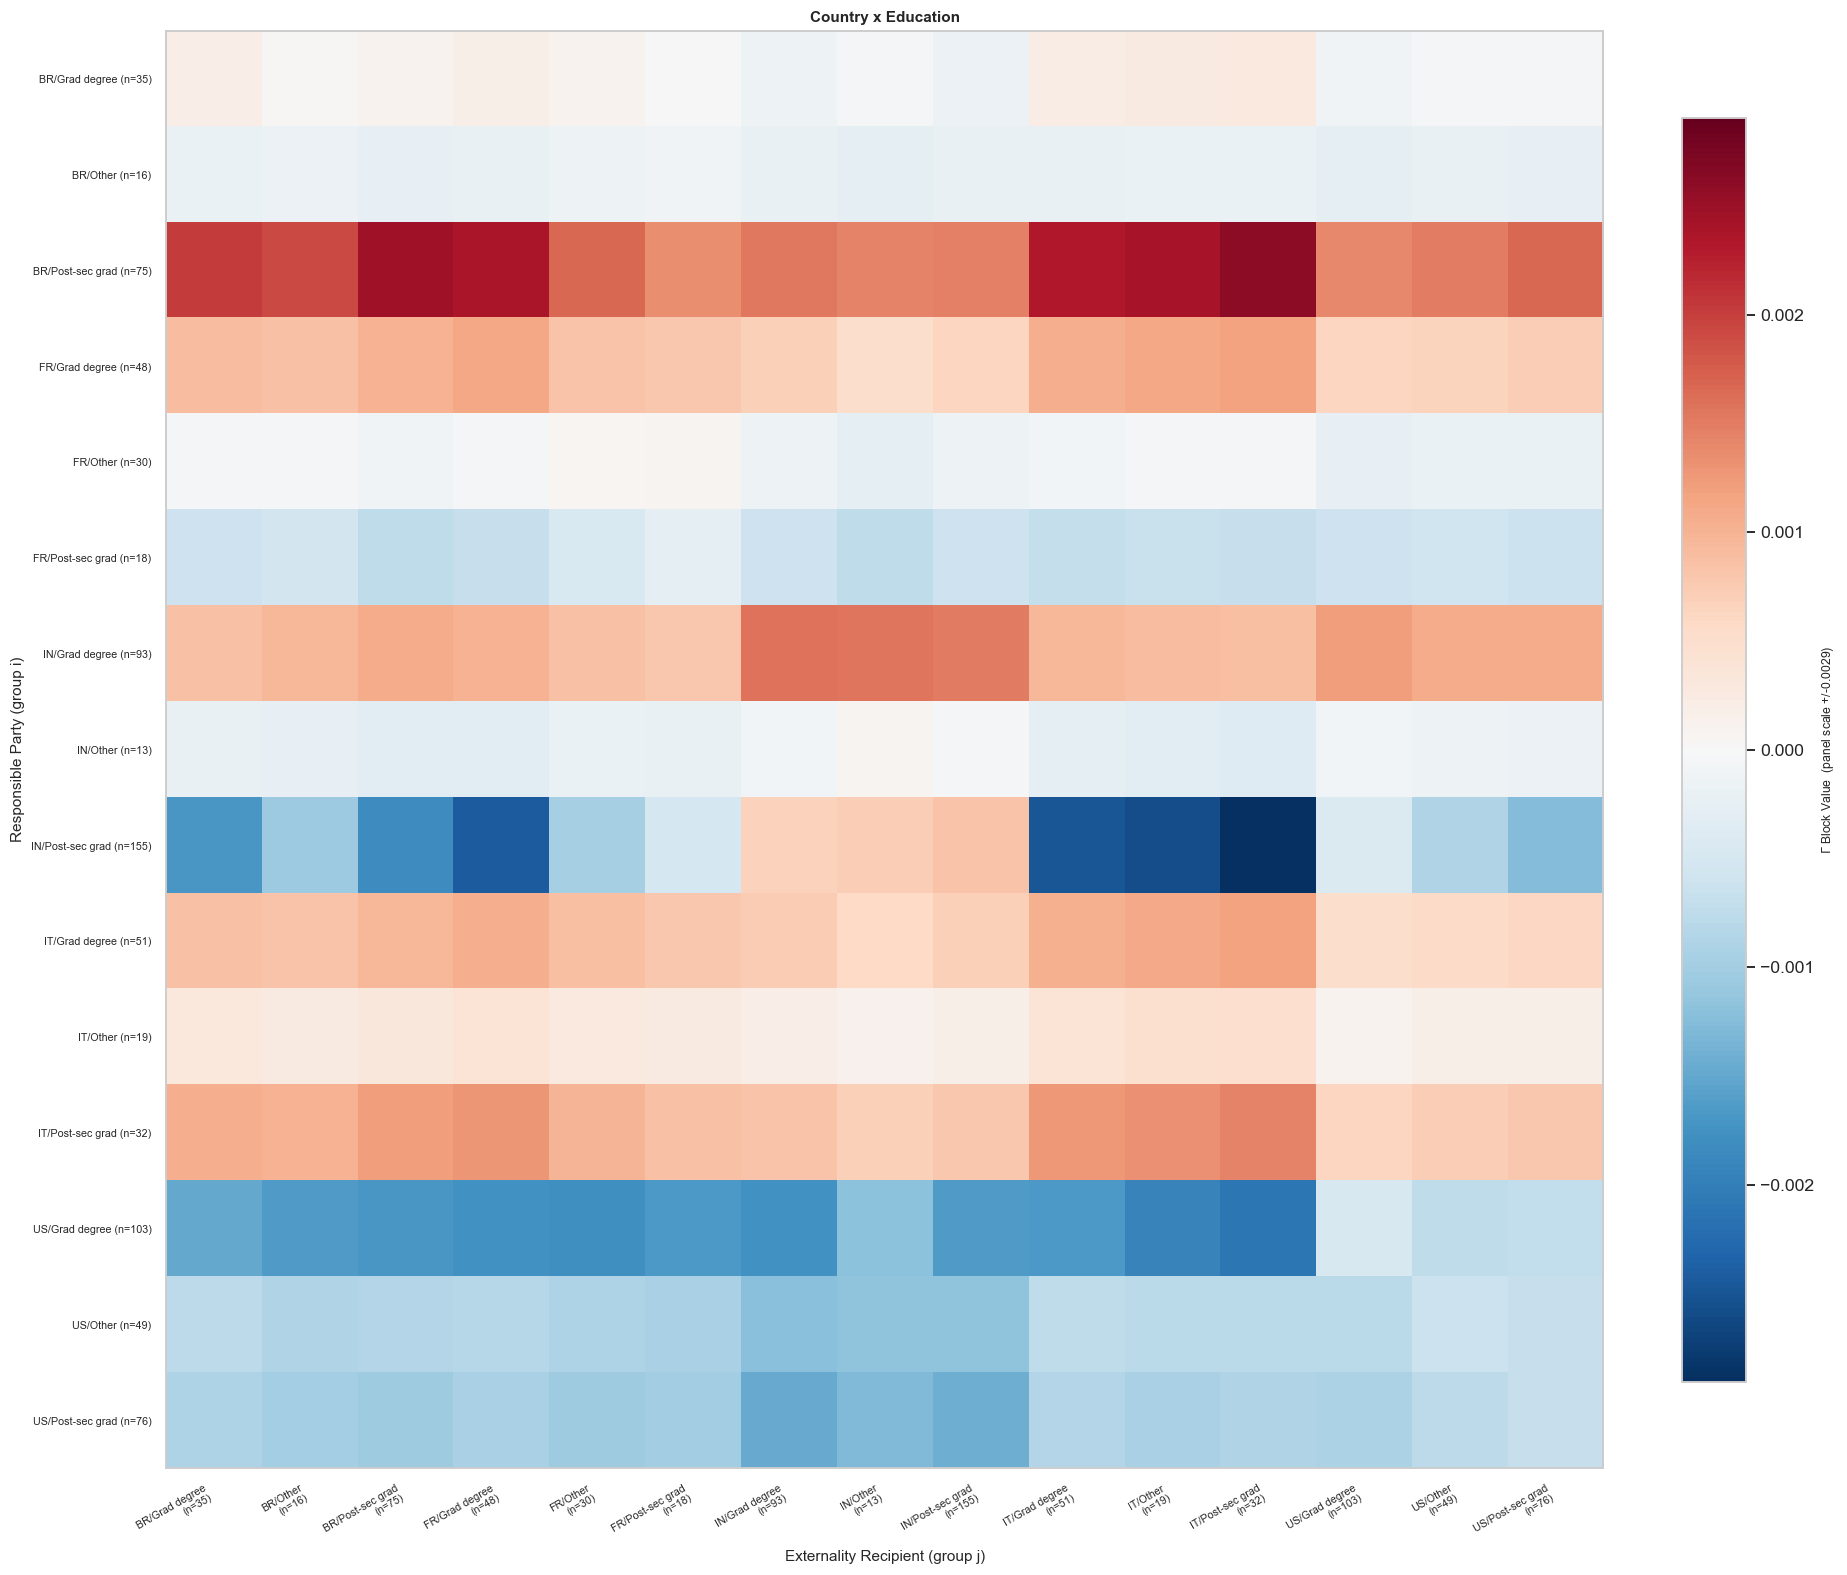


=== pair-averaged vs group-LOO comparison (rows = demographic axis) ===
                    pair-averaged Γ                     group-LOO Γ                    
                             within    across      diff      within    across      diff
axis                                                                                   
Country                    0.000011  0.000006  0.000005    0.001478 -0.000094  0.001572
Gender                     0.000001  0.000000  0.000000    0.000374  0.000052  0.000322
Age                       -0.000002 -0.000001 -0.000001    0.001038  0.000560  0.000478
Political                  0.000003  0.000003 -0.000000    0.000635  0.000324  0.000311
Education                  0.000001  0.000001 -0.000000    0.000450  0.000154  0.000296
Ethnicity                  0.000005  0.000003  0.000002    0.000773 -0.000113  0.000886
Country x Political        0.000012  0.000005  0.000006    0.000560  0.000002  0.000558
Country x Gender           0.000010  0.000005  

In [ ]:
# §7.6 — Group-level LOO heatmaps + comparison to §7.4/§7.5 pair-averaged.

import time

def _fit_loo_for_group(agents_in_G):
    keep_rows = ~np.isin(person_id, list(agents_in_G))
    lr = LogisticRegression(fit_intercept=False, C=BTL_C, solver="lbfgs",
                            max_iter=500, tol=1e-5)
    lr.fit(alpha_train[keep_rows], y_train[keep_rows])
    return psi(lr.coef_.ravel(), alpha_train, 1.0)

def group_loo_summary(group_arr, min_n=MIN_CELL_N):
    arr = pd.Series(group_arr).where(lambda s: s.notna(), None).fillna("(missing)").to_numpy()
    counts_all = pd.Series(arr).value_counts()
    keep = set(counts_all[counts_all >= min_n].index)
    mask = np.array([g in keep for g in arr])
    if mask.sum() < 2:
        return None
    arr_kept       = arr[mask]
    Theta_kept     = Theta[mask]
    agent_ids_kept = agent_ids[mask]
    uniq           = sorted(np.unique(arr_kept).tolist())

    # Refit ψ_{-G} for each group, in parallel.
    agents_per_group = {G: set(agent_ids_kept[arr_kept == G].tolist()) for G in uniq}
    psi_list = Parallel(n_jobs=-1, verbose=0)(
        delayed(_fit_loo_for_group)(agents_per_group[G]) for G in uniq
    )
    psi_minus = dict(zip(uniq, psi_list))

    # Responsible Party x Externality Recipient matrix in new convention.
    # G_mat[i, j] = theta_avg_{group j}^T (psi_full - psi_{-group i})
    # = welfare effect on Recipient group j from removing all of Responsible group i.
    G_mat = np.zeros((len(uniq), len(uniq)))
    for i, gn in enumerate(uniq):                                  # gn = Responsible Party group
        for j, gm in enumerate(uniq):                              # gm = Externality Recipient group
            theta_avg_gm = Theta_kept[arr_kept == gm].mean(axis=0)
            G_mat[i, j] = float(theta_avg_gm @ (psi_rlhf - psi_minus[gn]))
    return G_mat, uniq, {g: int((arr_kept == g).sum()) for g in uniq}, int((~mask).sum())

def plot_group_loo(ax, group_arr, label, fs_lab=8):
    res = group_loo_summary(group_arr)
    if res is None:
        ax.set_visible(False); return None
    G_mat, uniq, counts, n_drop = res
    vs = float(np.max(np.abs(G_mat))) or 1e-12
    im = ax.imshow(G_mat, cmap="RdBu_r", vmin=-vs, vmax=vs)
    ax.set_xticks(range(len(uniq)))
    ax.set_xticklabels([f"{g}\n(n={counts[g]})" for g in uniq],
                       fontsize=fs_lab, rotation=30, ha="right")
    ax.set_yticks(range(len(uniq)))
    ax.set_yticklabels([f"{g} (n={counts[g]})" for g in uniq], fontsize=fs_lab)
    ax.set_xlabel("Externality Recipient (group j)", fontsize=10)
    ax.set_ylabel("Responsible Party (group i)", fontsize=10)
    ax.grid(False)
    cb = plt.colorbar(im, ax=ax, fraction=0.04)
    cb.set_label(f"$\\Gamma$ Block Value  (panel scale +/-{vs:.4f})", fontsize=8)
    diag = float(np.diag(G_mat).mean())
    off  = float(G_mat[~np.eye(len(uniq), dtype=bool)].mean()) if len(uniq) > 1 else np.nan
    title = f"{label}"
    if n_drop: title += f"\ndropped {n_drop} agents in cells with n<{MIN_CELL_N}"
    ax.set_title(title, fontsize=10, fontweight="bold")
    return {"axis": label, "n_groups": len(uniq),
            "within": diag, "across": off, "diff": diag - off, "dropped": n_drop}

# 1) Single demographics — 2×3 grid.
t0 = time.time()
print("running group-level LOO refits for single demographic axes...")
fig, axes = plt.subplots(2, 3, figsize=(18, 11.5))
single_grouploo = [plot_group_loo(ax, demo_df[c].to_numpy(), l)
                   for ax, (c, l) in zip(axes.flat, SINGLE)]
fig.suptitle(r"$\Gamma_{i,j}$ heatmaps by demographic, pooled within-group",
             fontsize=16, y=0.85)
plt.tight_layout(rect=[0, 0, 0.95, 0.85]); plt.show()
print(f"  single demographics done in {time.time()-t0:.1f}s")

# 2) Cross demographics — one figure per axis.
cross_grouploo = []
for col, label in CROSS:
    g_arr = demo_df[col].to_numpy()
    g_clean = pd.Series(g_arr).where(lambda s: s.notna(), None).fillna("(missing)")
    n_keep = (g_clean.value_counts() >= MIN_CELL_N).sum()
    side = max(7.0, min(16.0, 1.0 + 0.9 * n_keep))
    fig, ax = plt.subplots(figsize=(side + 2, side))
    row = plot_group_loo(ax, g_arr, label, fs_lab=7)
    if row: cross_grouploo.append(row)
    plt.tight_layout(); plt.show()

# 3) Side-by-side comparison: pair-averaged (§7.4-7.5) vs group-LOO (§7.6).
all_pair = [r for r in (single_rows + cross_rows) if r is not None]
all_gloo = [r for r in (single_grouploo + cross_grouploo) if r is not None]
pair_df = pd.DataFrame(all_pair).set_index("axis")[["within", "across", "diff"]]
gloo_df = pd.DataFrame(all_gloo).set_index("axis")[["within", "across", "diff"]]
combined = pd.concat({"pair-averaged Γ": pair_df, "group-LOO Γ": gloo_df}, axis=1)
print("\n=== pair-averaged vs group-LOO comparison (rows = demographic axis) ===")
print(combined.round(6).to_string())

# 4) Group-LOO ranked by |within − across| — anonymous RLHF distorts most along this axis.
print("\n=== group-LOO axes ranked by |within − across| ===")
print(pd.DataFrame(all_gloo).sort_values("diff", key=abs, ascending=False)
      .round(6).to_string(index=False))

### §7.7 Utilitarian-receiver Γ̃ — per-annotator and per-group social-welfare contribution

For each Responsible Party n, define the **utilitarian-receiver externality**:

$$\tilde\Gamma_n \;=\; \bar\theta_w^\top \bigl(\psi_{\rm full} - \psi_{-n}\bigr)$$

By Lemma 1 ($W = \bar\theta_w^\top \psi$), this is **literally the change in social welfare caused by n\'s inclusion in the training pool**: $\tilde\Gamma_n = W_{\rm full} - W_{-n}$. Mechanically it\'s the **row-mean of Γ** (averaging over Externality Recipients m with uniform weights).

What this gives us:
- **Per-annotator ranking** — top contributors and biggest drags on social welfare.
- **Per-group bar chart** for each demographic — average $\tilde\Gamma_n$ within each bucket, with ±1 SE error bars.
- **Group-LOO version** $\tilde\Gamma_G = \bar\theta_w^\top (\psi_{\rm full} - \psi_{-G})$ — removes the entire group at once, capturing within-group nonlinear effects. Compared side-by-side with the per-individual average to show how much within-group interaction matters.

**Tradeoff.** Collapsing rows of Γ to a single number per Responsible Party averages away the asymmetric distributional structure that §7.4-7.6 surface. A group whose data helps some recipients but hurts others can land $\tilde\Gamma_G \approx 0$ even when it\'s a major source of welfare *inequality*. So Γ̃ is the right view for "net social-welfare verdict per annotator/group"; the matrix Γ is the right view for distributional patterns.

row-mean vs direct θ̄_w^T computation: max diff = 2.71e-19  (should be ≤ 1e-15)

=== Top 10 social-welfare contributors (positive Γ̃_n) ===
     Annotator    Γ̃_n       Country Gender   Political   Age
61575077936161 0.00026 United States   Male       Right 35-45
61575013019611 0.00026         India   Male Center/None 18-34
61575004409946 0.00025 United States   Male        Left 35-45
61575230511981 0.00024 United States   Male       Right 35-45
61575073676425 0.00024 United States Female Center/None   55+
61574932177407 0.00024 United States   Male        Left 18-34
61575027298560 0.00024         India   Male       Right 46-54
61575102144774 0.00024 United States Female        Left 35-45
61572939577297 0.00023         India   Male       Right 35-45
61574917834269 0.00023 United States   Male Center/None   55+

=== Bottom 10 (negative Γ̃_n -- drag on social welfare) ===
     Annotator     Γ̃_n       Country Gender   Political   Age
61575052409614 -0.00032 United States   Male Center/No

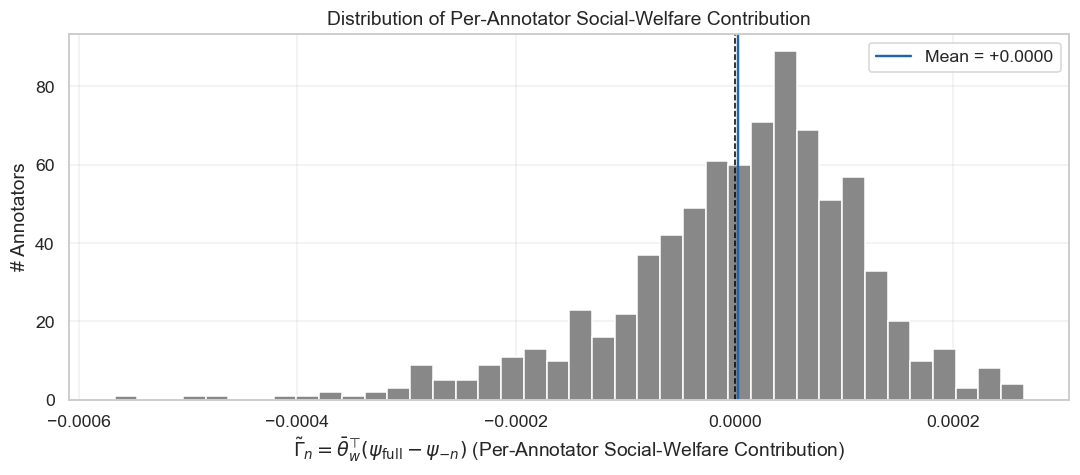

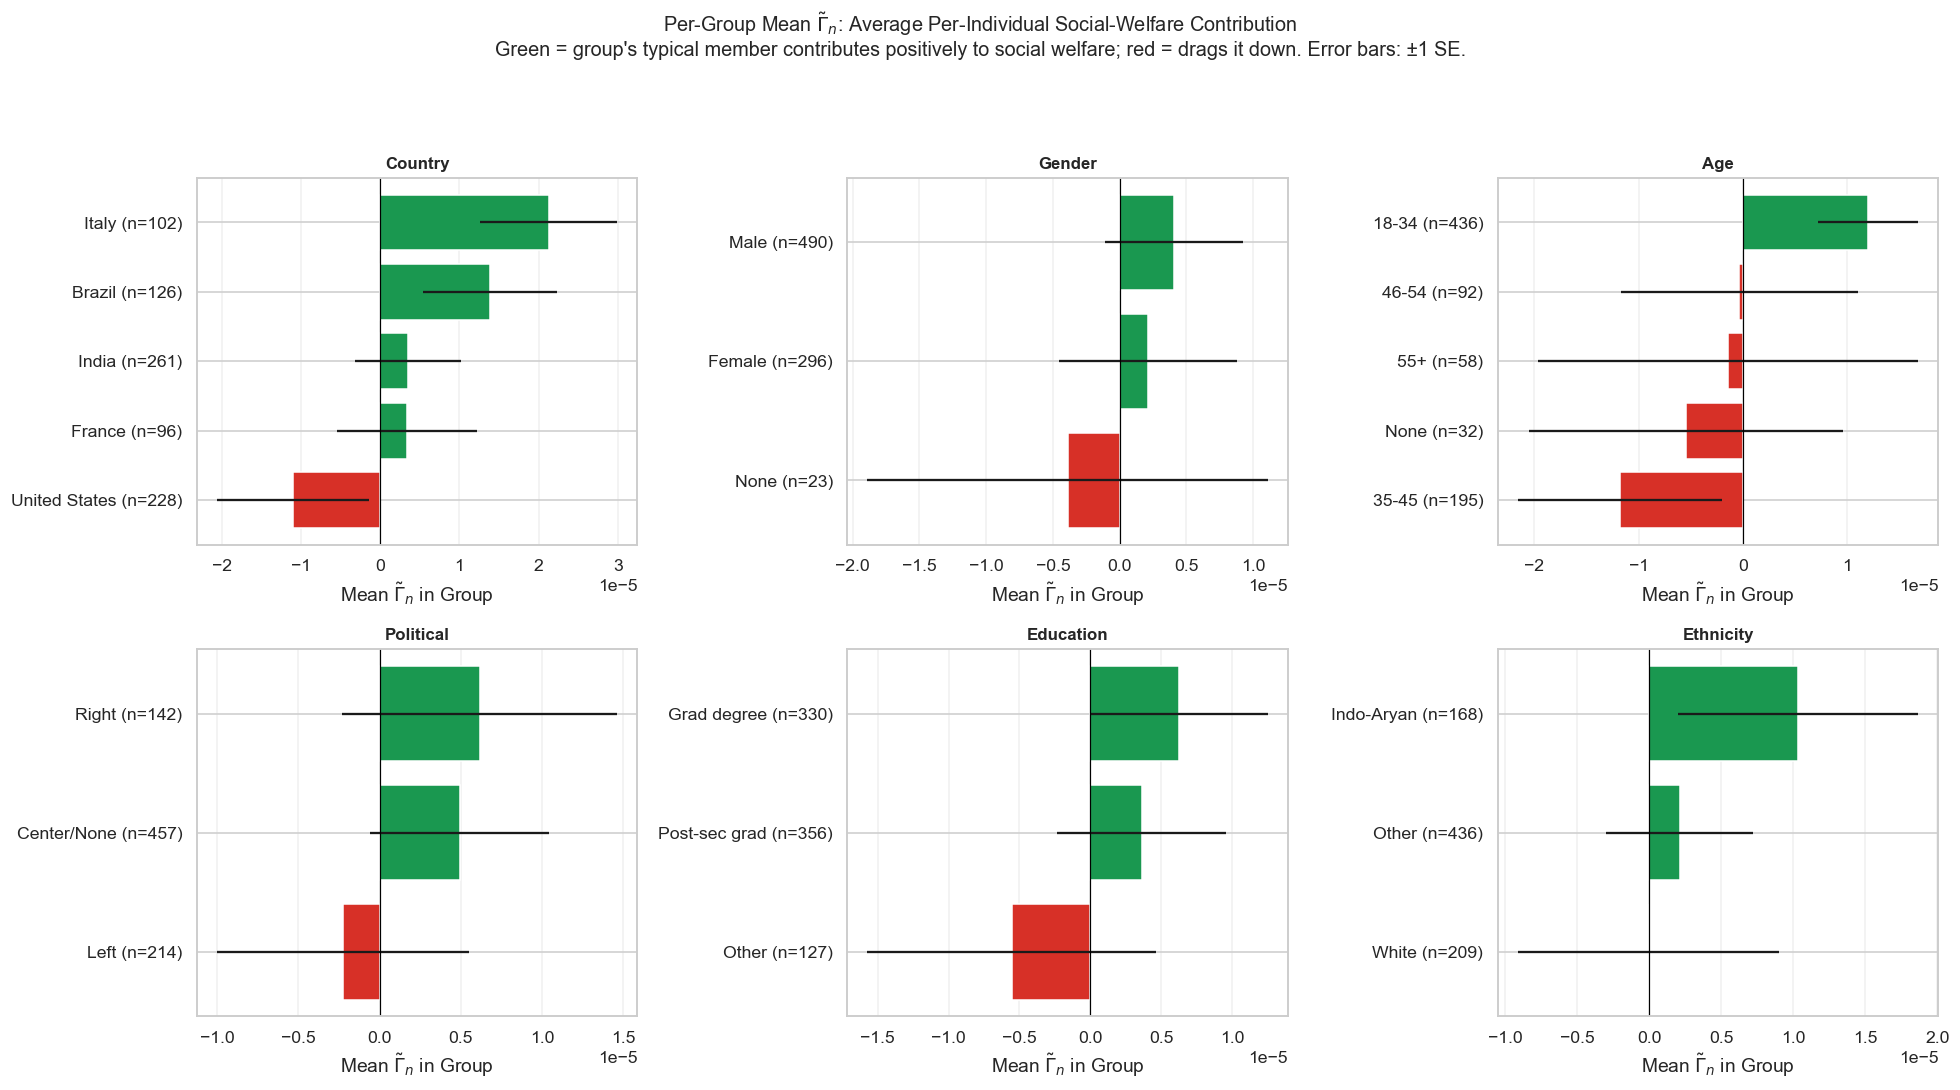


Group-LOO Γ̃_G = θ̄_w^T (ψ_full - ψ_{-G})  -- removes the ENTIRE group at once.
Compared with the per-individual average to show within-group interaction effects.

-- Country --
        Group   n  Γ̃_G (group-LOO)  Avg Γ̃_n     diff
        Italy 102           0.00210   0.00002  0.00208
       Brazil 126           0.00169   0.00001  0.00168
        India 261           0.00081   0.00000  0.00080
       France  96           0.00004   0.00000  0.00004
United States 228          -0.00339  -0.00001 -0.00337

-- Gender --
 Group   n  Γ̃_G (group-LOO)  Avg Γ̃_n     diff
  Male 490           0.00117       0.0  0.00117
  None  23          -0.00019      -0.0 -0.00018
Female 296          -0.00038       0.0 -0.00038

-- Age --
Group   n  Γ̃_G (group-LOO)  Avg Γ̃_n     diff
18-34 436           0.00836   0.00001  0.00835
  55+  58          -0.00024  -0.00000 -0.00024
 None  32          -0.00029  -0.00001 -0.00028
46-54  92          -0.00036  -0.00000 -0.00036
35-45 195          -0.00392  -0.00001 -

In [ ]:
# §7.7 — Utilitarian-receiver Γ̃: collapse Γ rows to a single social-welfare number per Responsible Party.

Gamma_tilde = Gamma.mean(axis=1)   # length N — Γ̃_n = row-mean of Γ

# Sanity: row-mean should equal direct computation θ̄_w^T (ψ_full − ψ_{-n})
delta_n_full = psi_rlhf[None, :] - psi_loo
Gamma_tilde_direct = delta_n_full @ theta_bar
resid = float(np.abs(Gamma_tilde - Gamma_tilde_direct).max())
print(f"row-mean vs direct θ̄_w^T computation: max diff = {resid:.2e}  (should be ≤ 1e-15)")
assert resid < 1e-12, "Γ̃ identity broken"

# 1) Per-annotator ranking with demographics
ann_table = pd.DataFrame({
    "Annotator": agent_ids,
    "Γ̃_n": Gamma_tilde,
    "Country":   demo_df["annotator_country"].to_numpy(),
    "Gender":    demo_df["annotator_gender"].to_numpy(),
    "Political": demo_df["political_3"].to_numpy(),
    "Age":       demo_df["annotator_age"].to_numpy(),
}).sort_values("Γ̃_n", ascending=False)

print(f"\n=== Top 10 social-welfare contributors (positive Γ̃_n) ===")
print(ann_table.head(10).round(5).to_string(index=False))
print(f"\n=== Bottom 10 (negative Γ̃_n -- drag on social welfare) ===")
print(ann_table.tail(10).round(5).to_string(index=False))

n_pos = int((Gamma_tilde > 0).sum())
print(f"\n{n_pos}/{len(Gamma_tilde)} annotators contribute positively to social welfare "
      f"({n_pos / len(Gamma_tilde):.0%})")
print(f"Γ̃_n stats:  mean = {Gamma_tilde.mean():+.5f}   std = {Gamma_tilde.std():.5f}   "
      f"range = [{Gamma_tilde.min():+.5f}, {Gamma_tilde.max():+.5f}]")

# 2) Distribution histogram
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(Gamma_tilde, bins=40, color="#888", edgecolor="white")
ax.axvline(0, color="black", lw=1, ls="--")
ax.axvline(Gamma_tilde.mean(), color="#2166ac", lw=1.6,
           label=f"Mean = {Gamma_tilde.mean():+.4f}")
ax.set_xlabel(r"$\tilde\Gamma_n = \bar\theta_w^\top (\psi_{\rm full} - \psi_{-n})$ (Per-Annotator Social-Welfare Contribution)")
ax.set_ylabel("# Annotators")
ax.set_title("Distribution of Per-Annotator Social-Welfare Contribution")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# 3) Per-group bar charts, one panel per single demographic
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, (col, label) in zip(axes.flat, SINGLE):
    g_arr = demo_df[col].astype(str).fillna("(missing)").to_numpy()
    counts = pd.Series(g_arr).value_counts()
    keep_groups = sorted([g for g in counts.index if counts[g] >= MIN_CELL_N])
    if not keep_groups:
        ax.set_visible(False); continue
    rows = []
    for g in keep_groups:
        m = g_arr == g
        rows.append({"group": g,
                     "mean": float(Gamma_tilde[m].mean()),
                     "n":    int(m.sum()),
                     "se":   float(Gamma_tilde[m].std()) / np.sqrt(m.sum())})
    grp_df = pd.DataFrame(rows).sort_values("mean")
    colors = ["#1a9850" if v >= 0 else "#d73027" for v in grp_df["mean"]]
    ylab = [f"{r.group} (n={r.n})" for r in grp_df.itertuples()]
    ax.barh(ylab, grp_df["mean"], xerr=grp_df["se"], color=colors, edgecolor="white")
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel(r"Mean $\tilde\Gamma_n$ in Group")
    ax.set_title(label, fontweight="bold", fontsize=11)
    ax.grid(True, axis="x", alpha=0.3)

fig.suptitle(r"Per-Group Mean $\tilde\Gamma_n$: Average Per-Individual Social-Welfare Contribution"
             "\nGreen = group's typical member contributes positively to social welfare; red = drags it down. Error bars: ±1 SE.",
             fontsize=13, y=0.99)
plt.tight_layout(rect=[0, 0, 1, 0.94]); plt.show()

# 4) Group-LOO comparison: Γ̃_G = θ̄_w^T (ψ_full - ψ_{-G}) — removes the WHOLE group at once
def _gloo_tilde_for_group(agents_in_G):
    keep = ~np.isin(person_id, list(agents_in_G))
    lr = LogisticRegression(fit_intercept=False, C=BTL_C, solver="lbfgs", max_iter=500, tol=1e-5)
    lr.fit(alpha_train[keep], y_train[keep])
    return float(theta_bar @ (psi_rlhf - psi(lr.coef_.ravel(), alpha_train, 1.0)))

print(f"\n{'='*78}")
print("Group-LOO Γ̃_G = θ̄_w^T (ψ_full - ψ_{-G})  -- removes the ENTIRE group at once.")
print("Compared with the per-individual average to show within-group interaction effects.")
print(f"{'='*78}")

for col, label in SINGLE:
    g_arr = demo_df[col].astype(str).fillna("(missing)").to_numpy()
    counts = pd.Series(g_arr).value_counts()
    keep_groups = sorted([g for g in counts.index if counts[g] >= MIN_CELL_N])
    if not keep_groups: continue
    agents_per_group = [set(agent_ids[g_arr == g].tolist()) for g in keep_groups]
    gloo_vals = Parallel(n_jobs=-1, verbose=0)(
        delayed(_gloo_tilde_for_group)(a) for a in agents_per_group
    )
    rows = []
    for g, gloo in zip(keep_groups, gloo_vals):
        m = g_arr == g
        rows.append({
            "Group":           g,
            "n":               int(m.sum()),
            "Γ̃_G (group-LOO)": float(gloo),
            "Avg Γ̃_n":         float(Gamma_tilde[m].mean()),
            "diff":            float(gloo - Gamma_tilde[m].mean()),
        })
    print(f"\n-- {label} --")
    print(pd.DataFrame(rows).sort_values("Γ̃_G (group-LOO)", ascending=False)
          .round(5).to_string(index=False))

### §7.8 Per-query welfare impact — the most-distorting queries

The social welfare gap decomposes per-query under the deployment distribution:

$$\Delta W \;=\; \mathbb{E}_{z\sim q_{\rm dep}}[\Delta w_z], \qquad \Delta w_z \;=\; \tfrac{1}{2}|\alpha_z^\top\bar\theta_w| \;-\; \alpha_z^\top\bar\theta_w \cdot \bigl(\sigma(\alpha_z^\top\hat\theta_{\rm RLHF}) - \tfrac{1}{2}\bigr)$$

By Prop 2 (ψ\* is the pointwise welfare maximum), each $\Delta w_z \ge 0$, and $\mathbb{E}[\Delta w_z]$ recovers $\Delta W$ exactly. So this **is** the kosher notion: per-query welfare loss is a non-negative decomposition of the social-welfare gap.

Algebraic simplification:

$$\Delta w_z \;=\; |\alpha_z^\top \bar\theta_w| \cdot \bigl(1 - \sigma\bigl(\mathrm{sign}(\alpha_z^\top \bar\theta_w) \cdot \alpha_z^\top \hat\theta_{\rm RLHF}\bigr)\bigr) \;=\; \underbrace{|s|}_{\text{stakes}} \cdot \underbrace{(1 - \sigma(\mathrm{sign}(s) \cdot t))}_{\text{RLHF miss rate} \in (0,1)}$$

The factorization is informative on its own: a query is high-impact either because $|s|$ is large (a lot of welfare is at stake on that query) or because RLHF disagrees with the utilitarian winner (sign mismatch or low confidence on the right side). High-impact queries that combine *both* are where alignment is failing hardest.

raw pairwise rows:           40,278
unique pairwise comparisons: 4,860  (12% of raw)
avg annotators per pair:     8.3

All Δw_z ≥ 0?  True    min = +1.53e-05
E_z[Δw_z] (uniform over unique queries) = +0.14331
ΔW from §6 (uniform over annotator-rows) = +0.14647
  (these differ because q_dep is per-row in §6 vs per-unique-query here —
   §6 weights heavy-rated comparisons more; the dedup view gives every
   unique deployment scenario equal weight.)


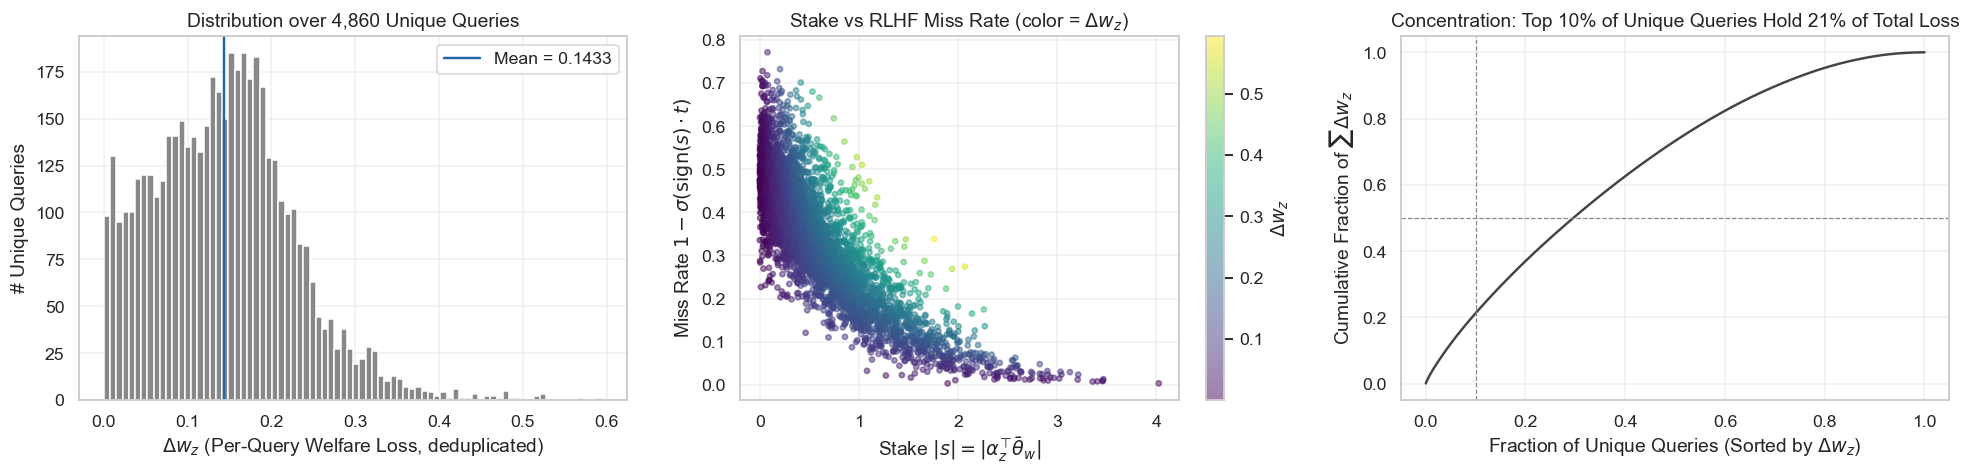


=== Top-15 highest-welfare-impacting UNIQUE queries (sorted by Δw_z) ===
  Δw_z  Stake |s|   Miss  Signal s  RLHF t                                                       Prompt                                            Preferred                                              Other
0.5949     1.7589 0.3382    1.7589  0.6713                    What are the benefits of bee pollination?   Bee pollination benefits include increased crop yi Bee pollination has significant cultural and spiri
0.5669     2.0689 0.2740   -2.0689 -0.9745                    What are the benefits of bee pollination?   Bee pollination has significant cultural and spiri The economic benefits of bee pollination cannot be
0.5256     1.0301 0.5103    1.0301 -0.0411 Can you recommend a good coffee mug, what material should I    Ceramic or glass mugs are good choices. They're no For a truly unique and environmentally conscious c
0.5218     1.1059 0.4719    1.1059  0.1127 What's a delicious and easy-to-make breakfast burri

In [ ]:
# §7.8 — Per-query welfare impact decomposition (DEDUPLICATED).
#
# A "query" in the formal sense is a unique pairwise comparison (choice_set + the
# unordered pair of responses being compared). Multiple annotators can vote on
# the same query, generating duplicate rows in the pairwise data — without
# deduping, popular comparisons get counted ~8x and dominate any ranking.
#
# Δw_z is invariant under sign flip of α_z (algebraic — verified below), so it
# doesn\'t matter which direction of the same pair we keep.

# 1) Build dedup key + filter to unique pairwise comparisons.
sub_q = sub.copy()
sub_q["_pair_key"] = list(zip(
    sub_q["choice_set_id"],
    sub_q[["preferred_text", "other_text"]].apply(frozenset, axis=1)
))
sub_unique = sub_q.drop_duplicates("_pair_key").reset_index(drop=True)
print(f"raw pairwise rows:           {len(sub_q):,}")
print(f"unique pairwise comparisons: {len(sub_unique):,}  ({len(sub_unique)/len(sub_q):.0%} of raw)")
print(f"avg annotators per pair:     {len(sub_q)/len(sub_unique):.1f}")

# 2) Build α_z and signals for the unique queries.
F_unique = (features.loc[sub_unique.preferred_text].to_numpy()
            - features.loc[sub_unique.other_text].to_numpy())
M_uniq   = F_unique.shape[0]
s_q   = F_unique @ theta_bar           # social preference signal
t_q   = F_unique @ theta_rlhf          # RLHF deployment signal
stake = np.abs(s_q)                    # |s|
miss  = 1.0 - sigmoid(np.sign(s_q) * t_q)   # RLHF miss rate ∈ (0,1)
delta_w_q = stake * miss               # per-query welfare loss

print(f"\nAll Δw_z ≥ 0?  {(delta_w_q >= -1e-12).all()}    min = {delta_w_q.min():+.2e}")
print(f"E_z[Δw_z] (uniform over unique queries) = {delta_w_q.mean():+.5f}")
print(f"ΔW from §6 (uniform over annotator-rows) = {Delta_W:+.5f}")
print(f"  (these differ because q_dep is per-row in §6 vs per-unique-query here —")
print(f"   §6 weights heavy-rated comparisons more; the dedup view gives every")
print(f"   unique deployment scenario equal weight.)")

# 3) Distribution + concentration.
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
axes[0].hist(delta_w_q, bins=80, color="#888", edgecolor="white")
axes[0].axvline(delta_w_q.mean(), color="#2166ac", lw=1.6,
                label=fr"Mean = {delta_w_q.mean():.4f}")
axes[0].set_xlabel(r"$\Delta w_z$ (Per-Query Welfare Loss, deduplicated)")
axes[0].set_ylabel("# Unique Queries")
axes[0].set_title(f"Distribution over {M_uniq:,} Unique Queries")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

sc = axes[1].scatter(stake, miss, s=12, alpha=0.5, c=delta_w_q, cmap="viridis")
axes[1].set_xlabel(r"Stake $|s| = |\alpha_z^\top \bar\theta_w|$")
axes[1].set_ylabel(r"Miss Rate $1 - \sigma(\mathrm{sign}(s)\cdot t)$")
axes[1].set_title("Stake vs RLHF Miss Rate (color = $\Delta w_z$)")
plt.colorbar(sc, ax=axes[1], label=r"$\Delta w_z$")
axes[1].grid(True, alpha=0.3)

sorted_dw = np.sort(delta_w_q)[::-1]
cum = np.cumsum(sorted_dw) / sorted_dw.sum()
axes[2].plot(np.arange(1, len(cum)+1) / len(cum), cum, color="#444", lw=1.6)
axes[2].axhline(0.5, color="#888", ls="--", lw=0.8)
axes[2].axvline(0.1, color="#888", ls="--", lw=0.8)
top_10pct = cum[int(0.1 * len(cum))]
axes[2].set_xlabel("Fraction of Unique Queries (Sorted by $\Delta w_z$)")
axes[2].set_ylabel(r"Cumulative Fraction of $\sum \Delta w_z$")
axes[2].set_title(f"Concentration: Top 10% of Unique Queries Hold {top_10pct:.0%} of Total Loss")
axes[2].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# 4) Top-K most-distorting unique queries.
TOP_K = 15
topk_idx = np.argsort(-delta_w_q)[:TOP_K]
topk_df = pd.DataFrame({
    "Δw_z":      delta_w_q[topk_idx],
    "Stake |s|": stake[topk_idx],
    "Miss":      miss[topk_idx],
    "Signal s":  s_q[topk_idx],
    "RLHF t":    t_q[topk_idx],
    "Prompt":    sub_unique.iloc[topk_idx].prompt_text.str[:60].values,
    "Preferred": sub_unique.iloc[topk_idx].preferred_text.str[:50].values,
    "Other":     sub_unique.iloc[topk_idx].other_text.str[:50].values,
})
print(f"\n=== Top-{TOP_K} highest-welfare-impacting UNIQUE queries (sorted by Δw_z) ===")
print(topk_df.round(4).to_string(index=False))

# 5) Worst single query — feature-by-feature decomposition.
worst_idx = topk_idx[0]
top_alpha = F_unique[worst_idx]
top_contrib = top_alpha * theta_bar
print(f"\n=== Worst unique query (idx {worst_idx}, Δw_z = {delta_w_q[worst_idx]:.4f}) ===")
print(f"Prompt: {sub_unique.iloc[worst_idx].prompt_text[:200]}")
print(f"\nPreferred (by majority): {sub_unique.iloc[worst_idx].preferred_text[:300]}")
print(f"\nOther:                   {sub_unique.iloc[worst_idx].other_text[:300]}")
print(f"\nFeature breakdown — α_z^T θ̄_w decomposed by dimension:")
print(pd.DataFrame({
    "Dimension":     DIM_NAMES,
    "α_z[j]":        top_alpha,
    "θ̄_w[j]":        theta_bar,
    "α_z[j]·θ̄_w[j]": top_contrib,
}).round(4).to_string(index=False))
print(f"\nSum (= s = α_z^T θ̄_w): {top_contrib.sum():+.4f}")

# 6) Complementary views — top stakes + top miss rates.
print(f"\n=== Top-10 highest-stake unique queries (largest |s|, regardless of RLHF) ===")
stake_top = np.argsort(-stake)[:10]
print(pd.DataFrame({
    "Stake |s|": stake[stake_top],
    "Miss":      miss[stake_top],
    "Δw_z":      delta_w_q[stake_top],
    "Prompt":    sub_unique.iloc[stake_top].prompt_text.str[:80].values,
}).round(4).to_string(index=False))

print(f"\n=== Top-10 worst-miss queries (RLHF most anti-aligned with utilitarian, |s|≥median) ===")
median_stake = float(np.median(stake))
qualified = stake >= median_stake
miss_top = np.argsort(-(miss * qualified.astype(float)))[:10]
print(pd.DataFrame({
    "Miss":      miss[miss_top],
    "Stake |s|": stake[miss_top],
    "Δw_z":      delta_w_q[miss_top],
    "Prompt":    sub_unique.iloc[miss_top].prompt_text.str[:80].values,
}).round(4).to_string(index=False))

## Summary

If you got here cleanly (no assertion failure on `W_n = θ_n^T ψ` in §3, `ΔW ≥ 0` in §6), the pipeline ran end-to-end on the full Community Alignment Dataset.

**What to read out:**
- §6's per-feature decomposition of `θ̄_w · Δψ_j` — which preference dimensions does anonymous RLHF *under-act* on, relative to the utilitarian welfare-optimum?
- §6's per-agent histogram of `ΔW_n` colored by group — does any one country/gender/political group disproportionately bear the welfare loss?
- §6.4's directional vs. magnitude split — how much of the gap is fundamental misalignment of the deployed policy direction vs. regularization shrinkage?
- §7.3's country-pair `Γ` summary — does adding annotators from country X help or hurt annotators from country Y?
- §7.6's KMeans-on-Θ cluster vs. country cross-tab — do preference-similar cohorts align with national borders, or cut across them?

**Caveats.** The 15 LLM-discovered dimensions have varying R² (see `summary.md` from the tarball — `Structure` is weakest at 0.58, `Efficiency` strongest at 0.89). 12 of 15 dimensions had low contrastive-vs-ridge cosine agreement, so trust the *signed direction* of effects more than the absolute magnitude per dimension. The three "reliable" ones are `Community Focus`, `Practicality`, `Authenticity`.